In [1]:
import numpy as np
import xarray as xr
#import scipy as sci
import matplotlib.pyplot as plt # still need matplotlib
import xmitgcm
import xgcm 
import gsw
import cmocean

In [7]:

# Loading .nc files with the relevant data: T, S, U, V, W 
PacPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Pacific-4C-Physical.nc'
PacPh = xr.open_dataset(PacPhnc)

SOPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Southern-4C-Physical.nc'
SOPh = xr.open_dataset(SOPhnc)

conPhnc = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/nc_files/Control-Physical.nc'
conPh = xr.open_dataset(conPhnc)



In [10]:
# Time average and mask the velocities
tran = np.arange(90,100)
wvSO = xr.where(SOPh.WVEL ==0, np.nan, SOPh.WVEL).isel(time = tran).mean('time')
wvPac = xr.where(PacPh.WVEL ==0, np.nan, PacPh.WVEL).isel(time = tran).mean('time')
wvcon = xr.where(conPh.WVEL ==0, np.nan, conPh.WVEL).isel(time = tran).mean('time')

vvSO = xr.where(SOPh.VVEL ==0, np.nan, SOPh.VVEL).isel(time = tran).mean('time')
vvPac = xr.where(PacPh.VVEL ==0, np.nan, PacPh.VVEL).isel(time = tran).mean('time')
vvcon = xr.where(conPh.VVEL ==0, np.nan, conPh.VVEL).isel(time = tran).mean('time')

uvSO = xr.where(SOPh.UVEL ==0, np.nan, SOPh.UVEL).isel(time = tran).mean('time')
uvPac = xr.where(PacPh.UVEL ==0, np.nan, PacPh.UVEL).isel(time = tran).mean('time')
uvcon = xr.where(conPh.UVEL ==0, np.nan, conPh.UVEL).isel(time = tran).mean('time')


In [14]:
# Same for the temperature and salinity

THSO = xr.where(SOPh.SALT ==0, np.nan, SOPh.THETA).isel(time = tran).mean('time')
SaSO= xr.where(SOPh.SALT ==0, np.nan, SOPh.SALT).isel(time = tran).mean('time')

THPac = xr.where(PacPh.SALT ==0, np.nan, PacPh.THETA).isel(time = tran).mean('time')
SaPac= xr.where(PacPh.SALT ==0, np.nan, PacPh.SALT).isel(time = tran).mean('time')

THcon= xr.where(conPh.SALT ==0, np.nan, conPh.THETA).isel(time = tran).mean('time')
Sacon= xr.where(conPh.SALT ==0, np.nan, conPh.SALT).isel(time = tran).mean('time')

In [40]:
sigcon = gsw.sigma0(Sacon, THcon)
sigPac = gsw.sigma0(SaPac, THPac)

## Figure 8: Overturning Streamfunctions

/glade/derecho/scratch/bataylor/tmp/ipykernel_54227/3164464706.py:4: RuntimeWarning: invalid value encountered in divide
  pma = pma/pma


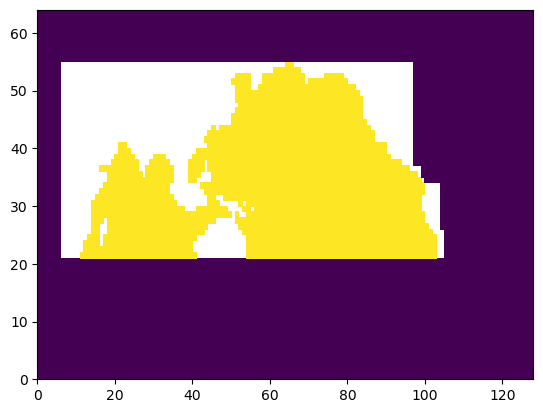

In [22]:
## define the mask for the Indian and Pacific basin 

pma = np.array(conPh.hFacC.isel(Z=0))
pma = pma/pma
#plt.pcolor(pma)


IPmask = pma
IPmask[0:21, :] = 0 
IPmask[55:64, :] = 0 
IPmask[:, 0:6] = 0 
#IPmask[:, 0:33] = 0 
IPmask[:, 105:] = 0 
IPmask[50:64, 100:] = 0 #

#AllTmask = TPmask
#IPmask[26:39, 0:36] = 0
IPmask[26:39, 104:]=0
IPmask[34:55, 100:]=0
IPmask[35:55, 99:]=0
IPmask[37:55, 97:]=0
#IPmask[17:31, 33:50] = 0
#TPmask[18:31, 33:50] = 0
plt.pcolor(IPmask)

In [24]:
# Calculating streamfunctions 

## Compute Pacific basin streamfunction
# note this creates a discontinuity at the ITF ...
masks = np.load('Yohei_2018/forcing_files_jan25/masks.npy')
# this mask just gives each basin a different number (Similar to Fig 3). 
vconP = vvcon.where(masks==1)#.mean('time')
transport = vconP*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv = transport.sum('XC').cumsum('Z')

# Consider the Pac-4C experiment
vconPf = vvPac.where(masks==1)#.mean('time')
transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvP = transportP.sum('XC').cumsum('Z')
#netv.isel(YG=range(17,53)).plot(ylim=[-500,0])

## compute Psi using full Indo-Pacific basin
vconf = vvcon.where(IPmask==1)#.mean('time')
transport = vconf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv2 = transport.sum('XC').cumsum('Z')

# Consider the SO-4C experiment
vconSf2 = vvSO.where(IPmask==1)#.mean('time')
transportS2 = vconSf2*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO2 = transportS2.sum('XC').cumsum('Z')

netdifSO2 = netvSO2 - netv2

## 

In [32]:
# For Subtropical Cell Index (STCI), only consider Pacific basin.

vconSf2 = vvSO.where(masks==1)#.mean('time')
transportS2 = vconSf2*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO3 = -transportS2.sum('XC').cumsum('Z')


print('Control STCI = ' +str((np.array(np.max(netv)) - np.array(np.min(netv)))/1e6 ))
print('Pacific-4C STCI = '+str((np.array(np.max(netvP)) - np.array(np.min(netvP)))/1e6) )
print('SO-4C STCI = '+str((np.array(np.max(netvSO3)) - np.array(np.min(netvSO3)))/1e6 ))

Control STCI = 42.925094
Pacific-4C STCI = 40.857036
SO-4C STCI = 43.32197


Text(0.65, 0.4, 'STCI(SO-4C)=43.3 Sv')

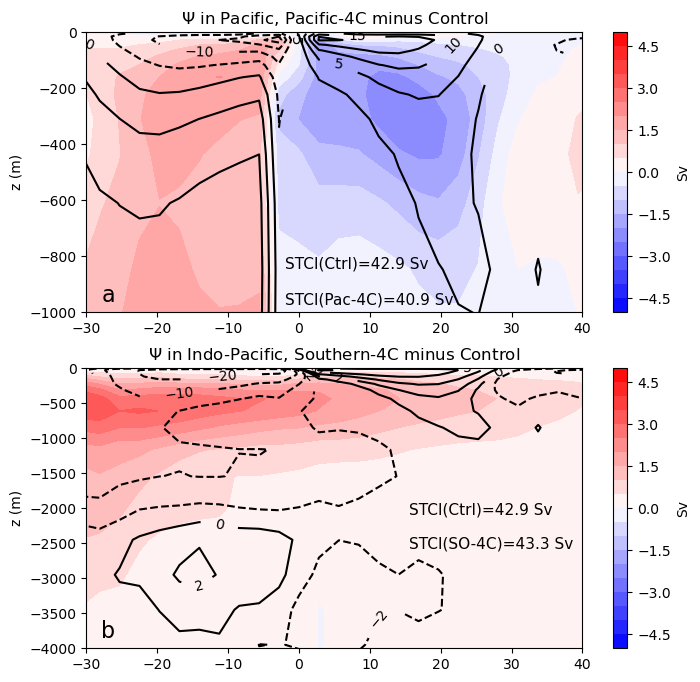

In [23]:
# Figure 8 plotting

fig, axs = plt.subplots(nrows=2, figsize=(8,8))



cl = axs[0].contour(netv.YG, netv.Z, netv/1e6, levels = np.arange(-20, 25, 5), colors= 'k')
cl.clabel()
axs[0].set_ylim([-1000,0])
axs[0].set_xlim([-30,40])
A = axs[0].contourf(netv.YG, netv.Z, (netvP - netv)/1e6, vmin = -5, vmax = 5, levels = np.linspace(-5,5,21), cmap='bwr')
cb1 = plt.colorbar(A, ax = axs[0])
cb1.set_label('Sv')
axs[0].set_title('$\\Psi$ in Pacific, Pacific-4C minus Control') 
axs[0].set_ylabel('z (m)')


iplevs = [-20,-10,-5,-2,0,2, 5, 10,  20]
cl2 = axs[1].contour(netv.YG, netv.Z, netv2/1e6, levels = iplevs, colors= 'k')
cl2.clabel( )
axs[1].set_ylim([-4000,0])
axs[1].set_xlim([-30,40])
B = axs[1].contourf(netv.YG, netv.Z, netdifSO2/1e6, vmin = -5, vmax = 5, levels =np.linspace(-5,5,21), cmap='bwr')
cb2= plt.colorbar(B, ax = axs[1])
cb2.set_label('Sv')
axs[1].set_title('$\\Psi$ in Indo-Pacific, Southern-4C minus Control')
axs[1].set_ylabel('z (m)')


axs[0].text(0.03, 0.1, 'a', fontsize=16, transform=axs[0].transAxes, ha='left', va='top')
axs[0].text(0.4, 0.2, 'STCI(Ctrl)=42.9 Sv', fontsize=11, transform=axs[0].transAxes, ha='left', va='top')
axs[0].text(0.4, 0.07, 'STCI(Pac-4C)=40.9 Sv', fontsize=11, transform=axs[0].transAxes, ha='left', va='top')
#40.754176

axs[1].text(0.03, 0.1, 'b', fontsize=16, transform=axs[1].transAxes, ha='left', va='top')
axs[1].text(0.65, 0.52, 'STCI(Ctrl)=42.9 Sv', fontsize=11, transform=axs[1].transAxes, ha='left', va='top')
axs[1].text(0.65, 0.4, 'STCI(SO-4C)=43.3 Sv', fontsize=11, transform=axs[1].transAxes, ha='left', va='top')


#plt.savefig('eps_figures/Streamfunctions11-29_2.eps')

## Figure 7: Velocity anomaly averages under Pacific-4C 

In [36]:
## calculating speed here! 

ylow = np.arange(20,53)
myX = np.arange(64,80) # could consider 60 to 80 ...  

# here I'm converting to numpy arrays to interpolate, I guess xarray wasn't working. 
# I find the speed first, then do the zonal mean, then subtract!

myV = np.array(vvcon.isel(YG = ylow+1, XC =myX).mean('XC'))
myU = np.array(uvcon.isel(YC = ylow, XG =myX).mean('XG'))
mySpeed = ((np.array(vvcon.isel(YG = ylow+1, XC =myX)) + np.array(vvcon.isel(YG = ylow, XC =myX)))**2)/4 + \
           (np.array(uvcon.isel(YC = ylow, XG =myX)) + np.array(uvcon.isel(YC = ylow, XG =myX+1)))**2 /4
mySp = np.nanmean(mySpeed**0.5,2) # zonal average speed

# same operations but for the Pac-4C experiment
myVpac = np.array(vvPac.isel(YG = ylow+1, XC =myX).mean('XC'))
myUpac = np.array(uvPac.isel(YC = ylow, XG =myX).mean('XG'))

mySpeed = ((np.array(vvPac.isel(YG = ylow+1, XC =myX)) + np.array(vvPac.isel(YG = ylow, XC =myX)))**2)/4 + \
           (np.array(uvPac.isel(YC = ylow, XG =myX)) + np.array(uvPac.isel(YC = ylow, XG =myX+1)))**2 /4
mySpPac = np.nanmean(mySpeed**0.5,2) 



speeddif = mySpPac- mySp


/glade/derecho/scratch/bataylor/tmp/ipykernel_54227/1020114714.py:13: RuntimeWarning: Mean of empty slice
  mySp = np.nanmean(mySpeed**0.5,2) # zonal average speed
/glade/derecho/scratch/bataylor/tmp/ipykernel_54227/1020114714.py:21: RuntimeWarning: Mean of empty slice
  mySpPac = np.nanmean(mySpeed**0.5,2)


/glade/derecho/scratch/bataylor/tmp/ipykernel_54227/2340034204.py:68: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cb4 = plt.colorbar(I, ax= ax4)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


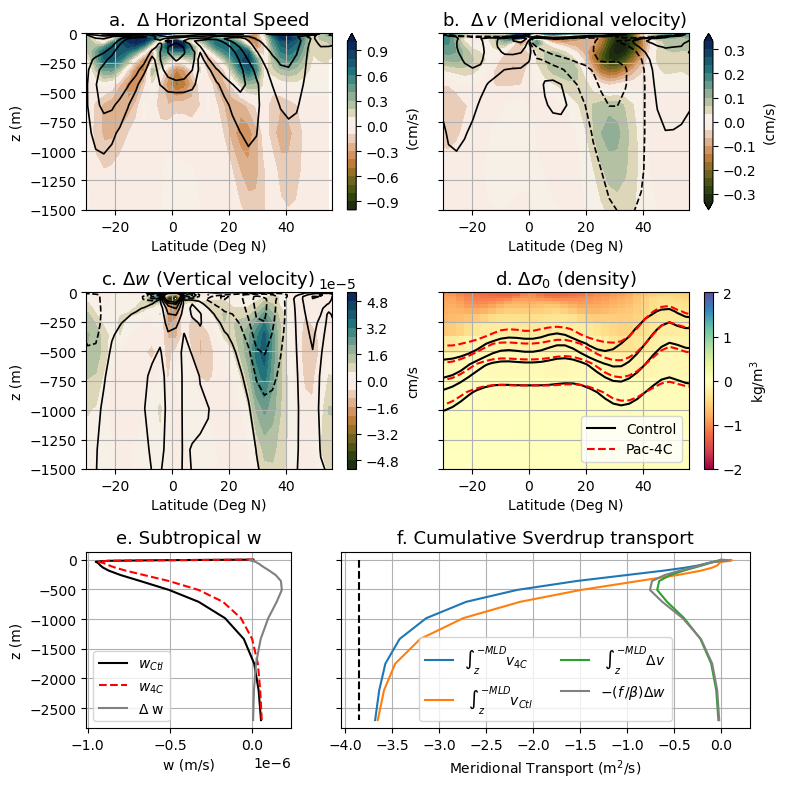

In [69]:
import matplotlib.gridspec as gridspec
# Create figure and subplots with gridspec to control width ratios

velmap = cmocean.cm.tarn

PacTr = PacPh
PacTS = PacPh
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(3, 2, figure=fig)

ylow = np.arange(20,53)
myX = np.arange(64,80)

tfon = 13

# First two rows: normal width ratio (1:1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

vm = 1
U = ax1.contourf(PacTr.YC[ylow], PacTr.Z, 100*speeddif, vmin =-vm, vmax = vm,levels = np.linspace(-vm, vm,21) , extend = 'max',cmap = velmap)
cb1 = plt.colorbar(U, ax = ax1)
ax1.contour(PacTr.YC[ylow], PacTr.Z,100*(myV**2 + myU**2)**0.5, levels = [1,2,5,10],colors = 'k', linewidths = 1.2)
ax1.set_title('a.  $\Delta$ Horizontal Speed ', fontsize = tfon) 
#ax1.set_xlabel('Latitude (Deg N)')
cb1.set_label('(cm/s)')#,fontsize=10)

vm = 1/3
A = ax2.contourf(PacTS.YG[ylow+1], PacTS.Z,100*(myVpac-myV) , vmin =-vm, vmax = vm, levels =np.linspace(-vm,vm, 21), extend = 'both', cmap = velmap) # why the weird thing? 
cb2 = plt.colorbar(A, ax = ax2)
ax2.contour(PacTS.YG[ylow+1], PacTS.Z, 100*(myV), levels = [-0.5,-0.1, 0.1, 0.5, 2], colors = 'k', linewidths = 1.2)
ax2.set_title('b.  $\Delta \, v$ (Meridional velocity) ', fontsize = tfon) 
cb2.set_label('(cm/s)')#,fontsize=10)
#ax2.set_xlabel('Latitude (Deg N)')
plt.grid()


vm = 0.000048*10/9

#plt.figure(figsize =[5,2])

myWpac = np.array(wvPac.isel(YC = ylow, XC =myX).mean('XC'))
myW = np.array(wvcon.isel(YC = ylow, XC =myX).mean('XC'))

W = ax3.contourf(PacTS.YC[ylow], PacTS.Zl,100*(myWpac-myW) , vmin =-vm, vmax = vm, levels =np.linspace(-vm, vm, 21), cmap = velmap)
cb3 = plt.colorbar(W, ax = ax3)
cb3.set_label('cm/s')
ax3.contour(PacTS.YC[ylow], PacTS.Zl, 100*(myW), levels = np.arange(-3e-4,3e-4, 5e-5), colors = 'k',linewidths = 1.2)
ax3.set_title('c. $\Delta w$ (Vertical velocity) ', fontsize = tfon)


#plt.figure(figsize =[5,4])
sigsouth =sigcon.isel(XC = myX, YC = ylow).mean('XC')
#signorth =sigcon.isel(XC = myX, YC = ylow+1)
sigPsouth = sigPac.isel(XC = myX, YC = ylow).mean('XC')
#sigPnorth = sigPac.isel(XC = myX, YC = ylow+1)

# OK finish this up real quick.
# pick a few contour levels that I want 
# this is so sketchy, I need to fix this ... 
y30 = np.argmin(np.abs(np.array(PacTS.YC[ylow]-40)))
siglevs = [sigsouth[8,y30],sigsouth[10, y30], sigsouth[11,y30], sigsouth[12,y30]] 
sigPlevs = [sigPsouth[8,y30], sigPsouth[10, y30], sigPsouth[11,y30], sigPsouth[12,y30]] 
# clev = np.linspace(-1,1,21)
I = ax4.pcolor(PacTS.YC[ylow], PacTS.Z, sigPsouth - sigsouth, vmin = -2, vmax =2,cmap = 'Spectral')
cb4 = plt.colorbar(I, ax= ax4)
cb4.set_label('kg/m$^3$')
ax4.set_title('d. $\Delta \sigma_0$ (density)', fontsize = tfon)
ax4.contour(PacTS.YC[ylow], PacTS.Z, sigsouth, colors = 'k', levels = siglevs, )
ax4.contour(PacTS.YC[ylow], PacTS.Z, sigPsouth, colors = 'r', linestyles = '--', levels = sigPlevs)
#ax4.legend(['Ctrl', 'Pac-4C'])

from matplotlib.lines import Line2D

    # Create proxy artists
legend_elements = [Line2D([0], [0], color='black', lw=1.5, label='Control'),
                    Line2D([0], [0], color='red', lw=1.5, linestyle='dashed', label='Pac-4C')]
ax4.legend(handles=legend_elements, loc='lower right')

ax4.grid()

lets = ['a','b','c','d']

for i, ax in enumerate([ax1, ax2, ax3, ax4], 1):
    #ax.set_title(f"Subplot {i}")
    ax.grid()
    ax.set_xlim([-30,56])
    ax.set_ylim([-1500,0])
    ax.set_xlabel('Latitude (Deg N)')
    #ax.text(0.05, 0.12, lets[i-1], fontsize=16, transform=ax.transAxes, ha='left', va='top')


# Third row: create subgrid with custom width ratio
sub_gs = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[2, :], width_ratios=[1, 2]  # left thinner
)

ax5 = fig.add_subplot(sub_gs[0, 0])
ax6 = fig.add_subplot(sub_gs[0, 1])


#gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])  # Left is twice as wide

# Left subplot (wider)
#ax1 = fig.add_subplot(gs[0])
#ax1.plot(x, y1, label='sin(x)', color='blue')
#ax1.set_title('Wider Plot')
#ax1.legend()

xran2 = myX
yran2 = np.arange(40,48)
zran2 = np.arange(0,17)
zranw = np.arange(0,18)


#PlA = wvSO.isel( XC = xran, YC = yran, Zl= zran).mean('XC').mean('YC')
PlB = wvPac.isel(  XC = xran2, YC = yran2, Zl= zranw).mean('XC').mean('YC')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = wvcon.isel( XC = xran2, YC = yran2, Zl= zranw).mean('XC').mean('YC')

#ax3.set_title('w (cm/s)     ', loc = 'right', fontsize=10)
ax3.set_ylabel('z (m)')
ax1.set_ylabel('z (m)')
ax2.set_yticklabels([])
ax4.set_yticklabels([])
ax6.set_yticklabels([])


ax5.plot(Pl0, wvPac.Zl[zranw], 'k')
ax5.plot(PlB, wvPac.Zl[zranw], 'r--')
ax5.plot(PlB - Pl0, wvPac.Zl[zranw], 'gray')

ax5.legend(['$w_{Ctl}$', '$w_{4C}$', '$\\Delta$ w'])
ax5.set_title('e. Subtropical w', fontsize = tfon)
ax5.grid()
ax5.set_ylabel('z (m)')
ax5.set_xlabel('w (m/s)')

PlvP = vvPac.isel(  XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlvC = vvcon.isel( XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG')

vtr0  = PlvC  * PacTr.drF[zran2]
vtrP  = PlvP  * PacTr.drF[zran2]

# Right subplot (narrower)
#ax2 = fig.add_subplot(gs[1])
ax6.plot(np.cumsum(vtrP), PacTr.Zu[zran2])
ax6.plot(np.cumsum(vtr0), PacTr.Zu[zran2])
ax6.plot(np.cumsum(vtrP) - np.cumsum(vtr0), PacTr.Zu[zran2])
ax6.set_title('f. Cumulative Sverdrup transport', fontsize = tfon)

rad = 6371000
rot = 7.3e-5
#f= rot*2*np.sin(wvPac.YC[yran2]*np.pi/180)

# could this calculation be improved? Probably ... 
#beta = rot*2/rad*np.cos(wvPac.YC[yran2]*np.pi/180)
taux = np.load('Yohei_2018/forcing_files_jan25/taux.npy')
tauy = np.load('Yohei_2018/forcing_files_jan25/tauy.npy')
# interpolating and integrating curl(tau) with weights ... 
# using Stokes' Theorem 
tauxd = np.sum(taux[yran2[0], xran2]*np.array(SOPh.dxC.isel(XG=xran2, YC=yran2[0])) -taux[yran2[-1], xran2]*np.array(SOPh.dxC.isel(XG=xran2, YC=yran2[-1])))
tauyd = np.sum(tauy[yran2, xran2[-1]]*np.array(SOPh.dyC.isel(XC = xran2[-1], YG = yran2)) - tauy[yran2, xran2[0]]*np.array(SOPh.dyC.isel(XC = xran2[0], YG = yran2)))
tauxd2 = np.sum(taux[yran2[0]-1, xran2]*np.array(SOPh.dxC.isel(XG=xran2, YC=yran2[0]-1)) -taux[yran2[-1]+1, xran2]*np.array(SOPh.dxC.isel(XG=xran2, YC=yran2[-1]+1)))
tauyd2 = np.sum(tauy[yran2, xran2[-1]+1]*np.array(SOPh.dyC.isel(XC = xran2[-1]+1, YG = yran2)) - tauy[yran2, xran2[0]-1]*np.array(SOPh.dyC.isel(XC = xran2[0]-1, YG = yran2)))
mycurl = (tauxd+tauyd + tauxd2+ tauyd2) / np.array(SOPh.rA.isel(XC = xran2, YC = yran2).sum('XC').sum('YC')) / 2

beta= 2*np.cos(np.array(SOPh.YG[44]/180) * np.pi)/6370000 * 7.3e-5
f= rot*2*np.sin(wvPac.YC[yran2]*np.pi/180)

wdif = PlB-Pl0
#wprofP = -wvPac.isel(XC = xran2, YC = yran2, Zl= zran2).mean('XC').mean('YC') 
#wPl2 = (wprofP - wprofP[3])/np.mean(beta)*np.mean(f) 
ax6.plot(-wdif/np.mean(beta)*np.mean(f), wvPac.Zl[zranw], 'gray')

ax6.plot(0*PacTr.Zu[zran2] + mycurl/1035/beta, PacTr.Zu[zran2], 'k--')
#plt.plot(wPl2 , wvPac.Zl[zran2], 'red')
ax6.legend(['$\int_z^{-MLD} v_{4C}$ ', ' $\int_z^{-MLD} v_{Ctl}$ ' , ' $\int_z^{-MLD} \Delta v$ ', '$-(f \,/\\beta) \Delta w $'], ncol=2, fontsize = 10) #  '$\\nabla$x($\\tau)/\\rho_0 / \\beta$'], 
ax6.grid()
ax6.set_xlabel('Meridional Transport (m$^2$/s)')

#ax5.text(0.05, 0.74, 'e', fontsize=16, transform=ax5.transAxes, ha='left', va='top')
#ax6.text(0.09, 0.74, 'f', fontsize=16, transform=ax6.transAxes, ha='left', va='top')

plt.tight_layout()

#plt.savefig('eps_figures/vel_combined4_30_grids.eps',bbox_inches="tight")


## Figure Supp on Mixed Layer Depth anomalies in the control case. 

In [ ]:

# Ctl2d = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = 'Diag2d', iters = myItsTS.tolist(), ignore_unknown_vars = True)


NameError: name 'Ctl2d' is not defined

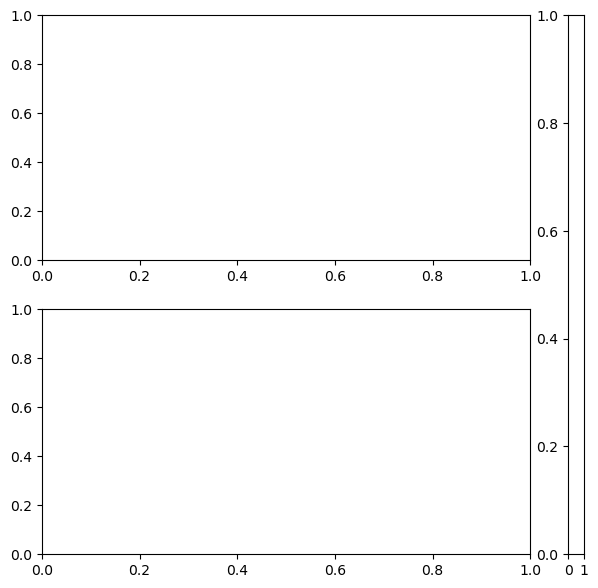

In [44]:
# Let's make a nice figure that compares the two. 

fig = plt.figure(figsize=(7, 7))

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[30, 1],   # main panels + colorbar
    wspace=0.15,
    hspace=0.2
)

# main axes
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])

# colorbar axis (spans both rows)
cax = fig.add_subplot(gs[:, 1])


#fig,axs = plt.subplots(nrows = 2, ncols=1, figsize=([6,7]))
vmin = 0
vmax = 600
toPl = Ctl2d.MXLDEPTH.isel(time = 7).where(Ctl2d.MXLDEPTH.isel(time=7)!=0, other=np.nan)
a=ax0.pcolor(Ctl2d.MXLDEPTH.XC, Ctl2d.MXLDEPTH.YC, MLDint.isel(iMONTH=7), vmin = vmin, vmax = vmax)
b=ax1.pcolor(Ctl2d.MXLDEPTH.XC, Ctl2d.MXLDEPTH.YC, toPl, vmin = vmin, vmax = vmax)

ax0.text(0.09, 0.87, 'a', fontsize=16, transform=ax0.transAxes,ha='left', va='top')
ax1.text(0.09, 0.87, 'b', fontsize=16, transform=ax1.transAxes,ha='left', va='top')
ax0.grid()
ax1.grid()
ax0.set_title('Argo Mixed Layer Depth, August mean')
ax1.set_title('MITgcm Control Mixed Layer Depth, August mean')


# shared colorbar
cb = fig.colorbar(a, cax=cax, shrink = 0.5)
cb.set_label('Mean MLD (m)')
#plt.colorbar(b, ax = axs[1], label='Mean MLD (m)')
#plt.colorbar(a, ax = axs[0], label='Mean MLD (m)')
#cax = fig.add_axes([0.92, 0.55, 0.02, 0.32])  # [left, bottom, width, height]
#cbmap = plt.colorbar(a, cax=axs[0], label='Mean MLD (m)')

#MLDdiff = Ctl2d.MXLDEPTH.isel(time=7) - MLDint.isel(iMONTH=7)

#MLDdiff.plot()
# plt.savefig('eps_figures/MLD_supp_12-22.eps', bbox_inches="tight")

Text(0.5, 1.0, 'Pacific 4C Warming')

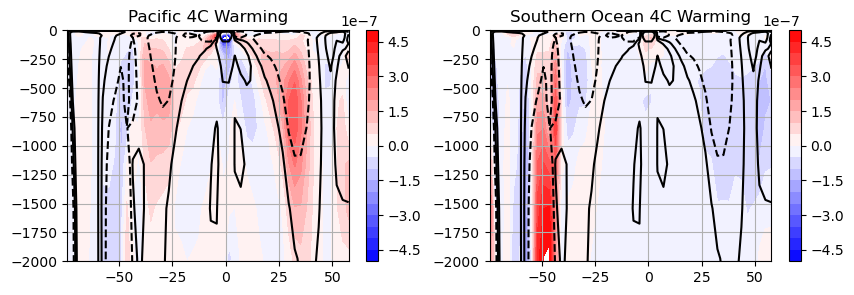

In [30]:
## Ok first let's just look at WVEL

fig, axs = plt.subplots(ncols=2 , figsize=(10,3))
xran = range(65,85)
yran = range(5,53)
zran = range(17)

PlA = wvPac.isel( XC = xran, YC = yran, Zl= zran).mean('XC')
PlB = wvSO.isel( XC = xran, YC = yran, Zl= zran).mean('XC')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = wvcon.isel(XC = xran, YC = yran, Zl= zran).mean('XC')

vm = 0.0000005


wlevels = [-3e-6, -0.5e-6,0,  0.5e-6, 3e-6]

Diag3d = PacTr

A = axs[0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlA - Pl0  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(A, ax= axs[0])
axs[0].set_ylim([-2000,0])
axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0].grid()

B = axs[1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlB- Pl0, vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(B, ax= axs[1])
axs[1].set_ylim([-2000,0])
axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[1].grid()


axs[1].set_title('Southern Ocean 4C Warming')
axs[0].set_title('Pacific 4C Warming')



In [21]:
# gotta test whether any of the wvel diagnostics are working ... maybe not! 
# shoulda tested this LOL... overconfidence ... yikes. # now I've got a bit of a pickle. 
# sheesh that was pretty silly! I thought it would throw an error if they didn't save. 
# OK gotta run a test now. 

In [31]:

foldi = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/diags/'


testTr = xmitgcm.open_mdsdataset(foldi, grid_dir = fol3, prefix = ['DynDiag3d','HeatBudget'], iters = 'all', ignore_unknown_vars = True)

### looking at WVEL in the Southern Ocean runs

In [121]:
## Ok here's scratch work on the wvel signal propagation ... 
## Select the year range here 

myYr = np.arange(1,30)
#print(myYr)
myIts = 2880000 + 720*myYr
#print(myIts)


In [73]:
fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
fol4 = '/glade/derecho/scratch/bataylor/23layer_YT/4CPac_try2/'
folSO = '/glade/derecho/scratch/bataylor/23layer_YT/4CSO_try2/'
fol0 = '/glade/derecho/scratch/bataylor/23layer_YT/control/'

PacTr = xmitgcm.open_mdsdataset(fol4, grid_dir = fol3, prefix = 'DynDiag3d', iters = 'all', ignore_unknown_vars = True)
vol = PacTr.drF*PacTr.hFacC*PacTr.rA
SOTr = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
CtlTr = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d'], iters = myIts.tolist(), ignore_unknown_vars = True)

In [122]:
#folPac50 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4C50SPac/'
fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
folPac50 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4C50SPac/'
folSO50 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4CSO_50S_try1/'
folSO = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4CSO_try1/'
fol0 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/Control_try1/'

SO50Tr = xmitgcm.open_mdsdataset(folSO50, grid_dir = fol3, prefix = 'DynDiag3d', iters = myIts.tolist(), ignore_unknown_vars = True)

SOTr = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['DynDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
CtlTr = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['DynDiag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)


vol = SOTr.drF*SOTr.hFacC*SOTr.rA

In [11]:

# new version
wvSO = xr.where(SOTr.WVEL ==0, np.nan, SOTr.WVEL)
wvSO50 = xr.where(SOTr.WVEL ==0, np.nan, SO50Tr.WVEL)
#wvcon= xr.where(CtlTr.WVEL ==0, np.nan, CtlTr.WVEL)
wvcon= xr.where(CtlTr.WVEL ==0, np.nan, CtlTr.WVEL)
wvPac = wvSO50 # just in case

In [74]:
wvSO = xr.where(SOTr.WVEL ==0, np.nan, SOTr.WVEL)
#ageSO= xr.where(SOTr.TRAC01 ==0, np.nan, SOTr.TRAC11).mean('time')
wvPac = xr.where(PacTr.WVEL ==0, np.nan, PacTr.WVEL)
#agePac= xr.where(PacTr.TRAC11 ==0, np.nan, PacTr.TRAC11).mean('time')
wvcon= xr.where(CtlTr.WVEL ==0, np.nan, CtlTr.WVEL)
#agecon= xr.where(CtlTr.TRAC11 ==0, np.nan, CtlTr.TRAC11).mean('time')

Text(0.5, 1.0, 'SO 50S cutoff 4Cstep')

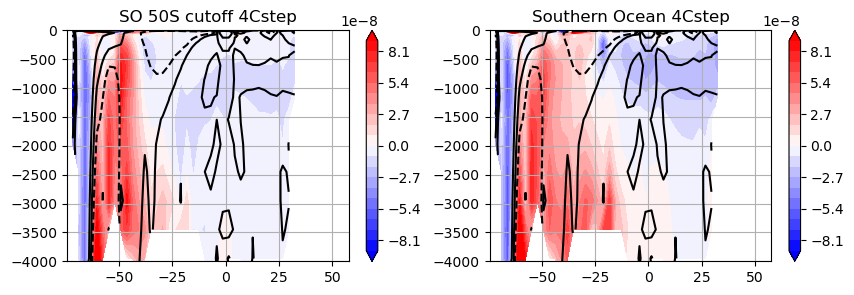

In [107]:
## Ok first let's just look at WVEL

fig, axs = plt.subplots(ncols=2 , figsize=(10,3))
xran = range(85,87)
yran = range(5,53)
zran = range(21)
PacTr=SOTr

myT = 6 # need to be a range. 

PlA = wvPac.isel(time = myT, XC = xran, YC = yran, Zl= zran).mean('XC')
PlB = wvSO.isel( time = myT, XC = xran, YC = yran, Zl= zran).mean('XC')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = wvcon.isel(time = myT, XC = xran, YC = yran, Zl= zran).mean('XC')

vm = 0.00000009


wlevels = [-3e-6, -0.5e-6,0,  0.5e-6, 3e-6]

Diag3d = PacTr

A = axs[0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlA - Pl0  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend= 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(A, ax= axs[0])
axs[0].set_ylim([-4000,0])
axs[0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[0].grid()

B = axs[1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlB- Pl0, vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(B, ax= axs[1])
axs[1].set_ylim([-4000,0])
axs[1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = wlevels)
axs[1].grid()


axs[1].set_title('Southern Ocean 4Cstep')
axs[0].set_title('SO 50S cutoff 4Cstep')



Text(0.5, 1.0, 'Time = 7')

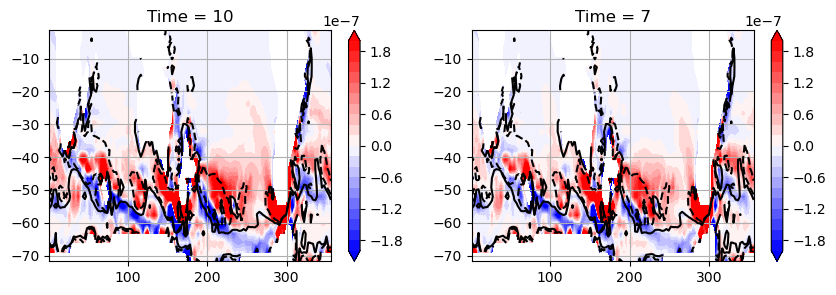

In [114]:
#So let's make maps instead ... I'm interested particularly in the Southern Ocean one... 

## Ok first let's just look at WVEL

fig, axs = plt.subplots(ncols=2 , figsize=(10,3))
xran = range(0,127)
yran = range(6,32)
zran = 13 # grid cells 11-14 have strongest response

myT = 10
myT2 = 7

PlA = wvSO50.isel(time = myT, XC = xran, YC = yran, Zl= zran)#.mean('Zl')
PlB = wvSO50.isel( time = myT2, XC = xran, YC = yran, Zl= zran)#.mean('Zl')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = wvcon.isel(time = myT, XC = xran, YC = yran, Zl= zran)#.mean('Zl')

vm = 0.0000002


wlevels = [-3e-6, -0.5e-6,  0.5e-6, 3e-6]
wlevels = [-0.5e-6,  0.5e-6]

Diag3d = PacTr

A = axs[0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], PlA - Pl0  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend= 'both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(A, ax= axs[0])
#axs[0].set_ylim([-2000,0])
axs[0].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
axs[0].grid()

B = axs[1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], PlB- Pl0, vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend='both')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
plt.colorbar(B, ax= axs[1])
#axs[1].set_ylim([-2000,0])
axs[1].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = wlevels)
axs[1].grid()


axs[0].set_title('Time = ' +str(myT))
axs[1].set_title('Time = '+str(myT2))




In [65]:
Diag3d.Zl[11:15]

<xarray.DataArray 'Zl' (Zl: 4)> Size: 16B
array([ -510.,  -710.,  -985., -1335.], dtype='>f4')
Coordinates:
  * Zl       (Zl) >f4 16B -510.0 -710.0 -985.0 -1.335e+03

In [16]:
SOTr.Zl.isel(Zl=zran)

<xarray.DataArray 'Zl' (Zl: 2)> Size: 8B
array([-360., -510.], dtype='>f4')
Coordinates:
  * Zl       (Zl) >f4 8B -360.0 -510.0

In [64]:
wvPac.YC[yran2]

<xarray.DataArray 'YC' (YC: 8)> Size: 32B
array([23.90625, 26.71875, 29.53125, 32.34375, 35.15625, 37.96875, 40.78125,
       43.59375], dtype='>f4')
Coordinates:
  * YC       (YC) >f4 32B 23.91 26.72 29.53 32.34 35.16 37.97 40.78 43.59

In [1]:
# redoing the latex

$w(z) \approx \frac{\nabla \times \vec{\tau}}{\rho_0 f} \,\,\exp{(\frac{z}{h})}$

$h \propto (g')^{-1/2} $

### evaluating terms of these equations

In [ ]:
# So I think I can basically compute these terms 
# and show that they satisfy the equations 

In [11]:
# terms are g', v, h???, w of course. 
# for Pacific and control ... 

# g' 
# basically need T and S. Those are standard diagnostics. 
fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
fol4 = '/glade/derecho/scratch/bataylor/23layer_YT/4CPac_try2/'
folSO = '/glade/derecho/scratch/bataylor/23layer_YT/4CSO_try2/'
fol0 = '/glade/derecho/scratch/bataylor/23layer_YT/control/'

PacTS = xmitgcm.open_mdsdataset(fol4, grid_dir = fol3, prefix = 'Diag3d', iters = myIts.tolist(), ignore_unknown_vars = True)
#vol = PacTr.drF*PacTr.hFacC*PacTr.rA
#SOT = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['DynDiag3d', 'AgeBudget3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
CtlTS = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['Diag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)


In [15]:
xran2 = np.arange(65,85)
yran2 = np.arange(40,48)
zran2 = np.arange(0,17)


#PlA = wvSO.isel( XC = xran, YC = yran, Zl= zran).mean('XC').mean('YC')
TP_1 = PacTS.THETA.isel(  XC = xran2, YC = yran2, Z= zran2).mean('XC').mean('YC').mean('time')
SP_1 = PacTS.SALT.isel(  XC = xran2, YC = yran2, Z= zran2).mean('XC').mean('YC').mean('time')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
TC_1 = CtlTS.THETA.isel( XC = xran2, YC = yran2, Z= zran2).mean('XC').mean('YC').mean('time')
SC_1 = CtlTS.SALT.isel( XC = xran2, YC = yran2, Z= zran2).mean('XC').mean('YC').mean('time')

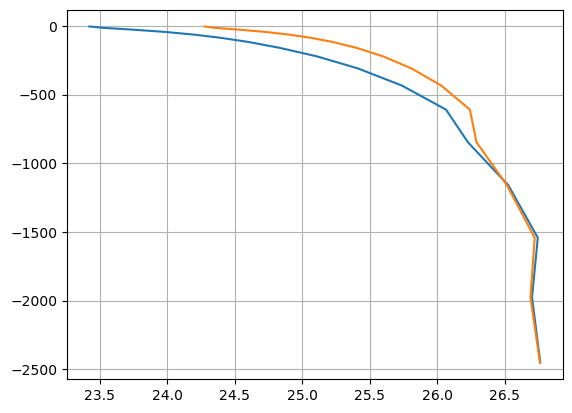

In [22]:
sigP_1 = gsw.sigma0(SP_1, TP_1)
sigC_1 = gsw.sigma0(SC_1, TC_1)
plt.plot( gsw.sigma0(SP_1, TP_1), PacTS.Z[zran2])
plt.plot( gsw.sigma0(SC_1, TC_1), PacTS.Z[zran2])
plt.grid()


In [34]:
g = 9.81
rho0 = 1035
drho_Pac = sigP_1[11]  - np.mean(sigP_1[0:6]) 
drho_Ctl = sigC_1[11]  - np.mean(sigC_1[0:6]) 

g_prime_Pac4c = float(g*(drho_Pac)/rho0)
g_prime_Ctl = float(g*(drho_Ctl)/rho0)

In [37]:
print(g_prime_Pac4c)
print(g_prime_Ctl)
print(g_prime_Pac4c/g_prime_Ctl)

0.017619671343606706
0.013144896132685808
1.3404192141004463


In [ ]:
# depending on which levels we choose, g' increases by 33 - 42% in the Pacific 4C run. Big difference!

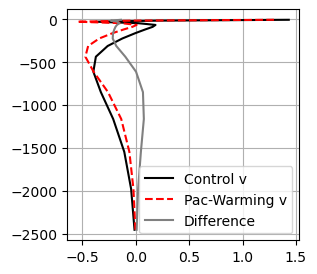

In [636]:
# Let's do the same exercise for v ... I think we can get neat profiles! 
# then try to connect v to changes in w! 
plt.figure(figsize=(3,3))
# It's very simple. 
# Just spatially mean w for each. 
# plot them. ''

# maybe do the difference. Maybe not ... 
# then maybe show a scale of how they change... 
# this is going to be a nice plot. I'm excited. 

xran2 = np.arange(65,80)
yran2 = np.arange(40,48)
zran2 = np.arange(0,17)

vvSO = xr.where(SOTr.VVEL ==0, np.nan, SOTr.VVEL)
#ageSO= xr.where(SOTr.TRAC01 ==0, np.nan, SOTr.TRAC11).mean('time')
vvPac = xr.where(PacTr.VVEL ==0, np.nan, PacTr.VVEL)
#agePac= xr.where(PacTr.TRAC11 ==0, np.nan, PacTr.TRAC11).mean('time')
vvcon= xr.where(CtlTr.VVEL ==0, np.nan, CtlTr.VVEL)
#agecon= xr.where(CtlTr.TRAC11 ==0, np.nan, CtlTr.TRAC11).mean('time')



#PlA = wvSO.isel( XC = xran, YC = yran, Zl= zran).mean('XC').mean('YC')
PlB = vvPac.isel(  XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG').mean('time')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = vvcon.isel( XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG').mean('time')

plt.plot(100*Pl0, vvPac.Z[zran2], 'k')
plt.plot(100*PlB, vvPac.Z[zran2], 'r--')
plt.plot(100*(PlB - Pl0), vvPac.Z[zran2], 'gray')

plt.legend(['Control v', 'Pac-Warming v', 'Difference'])
plt.grid()

# OK let's see how this transport looks! 
vtr0  = Pl0  * PacTr.drF[zran2]
vtrP  = PlB  * PacTr.drF[zran2]

In [80]:
# OK let's see how this transport looks! 
vtr0  = Pl0  * PacTr.drF[zran2]
vtrP  = PlB  * PacTr.drF[zran2]

In [101]:
print(float(sum(vtr0)))
float(sum(vtrP))

TypeError: only length-1 arrays can be converted to Python scalars

In [81]:
rad = 6371000
rot = 7.3e-5
f= rot*2*np.sin(wvPac.YC[yran2]*np.pi/180)

beta = rot*2/rad*np.cos(wvPac.YC[yran2]*np.pi/180)

In [188]:
PacTr

<xarray.Dataset> Size: 41MB
Dimensions:   (XC: 128, YC: 64, XG: 128, YG: 64, Z: 23, Zp1: 24, Zu: 23,
               Zl: 23, time: 10)
Coordinates: (12/34)
  * XC        (XC) >f4 512B 1.406 4.219 7.031 9.844 ... 350.2 353.0 355.8 358.6
  * YC        (YC) >f4 256B -88.59 -85.78 -82.97 -80.16 ... 82.97 85.78 88.59
  * XG        (XG) >f4 512B 0.0 2.812 5.625 8.438 ... 348.8 351.6 354.4 357.2
  * YG        (YG) >f4 256B -90.0 -87.19 -84.38 -81.56 ... 81.56 84.38 87.19
  * Z         (Z) >f4 92B -5.0 -15.0 -27.5 ... -4.45e+03 -4.95e+03 -5.45e+03
  * Zp1       (Zp1) >f4 96B 0.0 -10.0 -20.0 -35.0 ... -4.7e+03 -5.2e+03 -5.7e+03
    ...        ...
    rhoRef    (Z) >f4 92B dask.array<chunksize=(23,), meta=np.ndarray>
    dyF       (YC, XC) >f4 33kB dask.array<chunksize=(64, 128), meta=np.ndarray>
    dyU       (YG, XG) >f4 33kB dask.array<chunksize=(64, 128), meta=np.ndarray>
    dxF       (YC, XC) >f4 33kB dask.array<chunksize=(64, 128), meta=np.ndarray>
    iter      (time) int64 80B dask.array<chunksize=(1,), meta=np.ndarray>
  * time      (time) timedelta64[ns] 80B 13 days 06:00:00 ... 13 days 07:48:00
Data variables:
    UVEL      (time, Z, YC, XG) float32 8MB dask.array<chunksize=(1, 23, 64, 128), meta=np.ndarray>
    VVEL      (time, Z, YG, XC) float32 8MB dask.array<chunksize=(1, 23, 64, 128), meta=np.ndarray>
    WVEL      (time, Zl, YC, XC) float32 8MB dask.array<chunksize=(1, 23, 64, 128), meta=np.ndarray>
    VVELMASS  (time, Z, YG, XC) float32 8MB dask.array<chunksize=(1, 23, 64, 128), meta=np.ndarray>
    GM_Kwy    (time, Zl, YC, XC) float32 8MB dask.array<chunksize=(1, 23, 64, 128), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='/glade/derech...

Text(0, 0.5, 'z (m)')

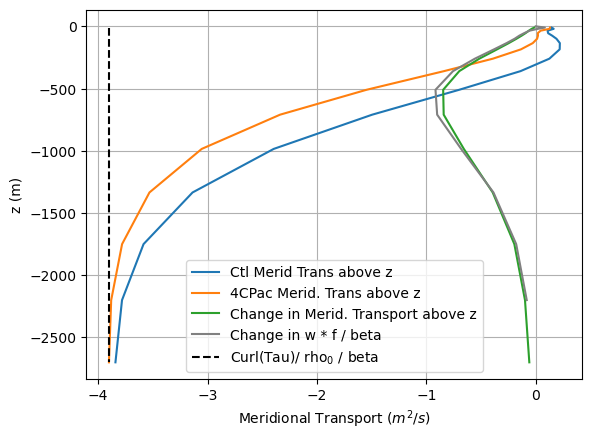

In [648]:
plt.plot(np.cumsum(vtr0), PacTr.Zu[zran2])
plt.plot(np.cumsum(vtrP), PacTr.Zu[zran2])
plt.plot(np.cumsum(vtrP) - np.cumsum(vtr0), PacTr.Zu[zran2])


wdif = wvPac.isel(  XC = xran2, YC = yran2, Zl= zran2).mean('XC').mean('YC') - wvcon.isel( XC = xran2, YC = yran2, Zl= zran2).mean('XC').mean('YC')
#wprofP = -wvPac.isel(XC = xran2, YC = yran2, Zl= zran2).mean('XC').mean('YC') 
#wPl2 = (wprofP - wprofP[3])/np.mean(beta)*np.mean(f) 
plt.plot(-wdif/np.mean(beta)*np.mean(f), wvPac.Zl[zran2], 'gray')

plt.plot(0*PacTr.Zu[zran2] - 3.898, PacTr.Zu[zran2], 'k--')
#plt.plot(wPl2 , wvPac.Zl[zran2], 'red')
plt.legend(['Ctl Merid Trans above z', '4CPac Merid. Trans above z', 'Change in Merid. Transport above z', 'Change in w * f / beta', 'Curl(Tau)/ rho$_0$ / beta'])
plt.grid()
plt.xlabel('Meridional Transport $(m^2/s)$')
plt.ylabel('z (m)')
            

$$ \beta v = f \frac{dw}{dz}$$ 


$$\frac{\beta}{f} \int_{z}^{-MLD}  v dz' = w(-MLD) - w(z)$$

$$\frac{\beta}{f} \int_{z}^{-MLD}  (v_{4C} - v_{Ctl}) dz' = - [w_{4C}(z) - w_{ctl}(z)]$$

In [ ]:
# This is something worth showing I think ... yeah I love this. BUT! 
# Lynne says show Sverdrup transport, I think she's right. Ok awesome, that looks great. 

In [98]:
# first grab the wind stress. 

# Numpy "fromfile" Function
# Ref: https://github.com/knaughten/mitgcm_python/blob/master/file_io.py
def set_dtype (prec, endian):

    if endian == 'big':
        dtype = '>'
    elif endian == 'little':
        dtype = '<'
    else:
        print('Error (set_dtype): invalid endianness')
        sys.exit()
    if prec == 32:
        dtype += 'f4'
    elif prec == 64:
        dtype += 'f8'
    else:
        print('Error (set_dtype): invalid precision')
        sys.exit()
    return dtype



In [99]:
prec = 32
endian = 'big'
dtype = set_dtype(prec, endian)
ff_taux = np.fromfile('Yohei_2018/forcing_files_jan25/trend_3601/taux_3601.bin', dtype = dtype)
taux = np.reshape(ff_taux, (3601, 64, 128))
taux = taux [0:12,:,:]
taux = np.mean(taux,0)

ff_tauy= np.fromfile('Yohei_2018/forcing_files_jan25/trend_3601/tauy_3601.bin', dtype = dtype)
tauy = np.reshape(ff_tauy, (3601, 64, 128))
tauy = tauy [0:12,:,:]
tauy = np.mean(tauy,0)


In [102]:
np.save('Yohei_2018/forcing_files_jan25/taux.npy', taux)
np.save('Yohei_2018/forcing_files_jan25/tauy.npy', tauy)

In [100]:
xran2 = np.arange(64,80)
yran2 = np.arange(40,48)
zran2 = np.arange(0,17)


tauxd = np.sum(taux[yran2[0], xran2]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2[0])) -taux[yran2[-1], xran2]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2[-1])))
tauyd = np.sum(tauy[yran2, xran2[-1]]*np.array(SOTr.dyC.isel(XC = xran2[-1], YG = yran2)) - tauy[yran2, xran2[0]]*np.array(SOTr.dyC.isel(XC = xran2[0], YG = yran2)))

tauxd2 = np.sum(taux[yran2[0]-1, xran2]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2[0]-1)) -taux[yran2[-1]+1, xran2]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2[-1]+1)))
tauyd2 = np.sum(tauy[yran2, xran2[-1]+1]*np.array(SOTr.dyC.isel(XC = xran2[-1]+1, YG = yran2)) - tauy[yran2, xran2[0]-1]*np.array(SOTr.dyC.isel(XC = xran2[0]-1, YG = yran2)))

mycurl = (tauxd+tauyd + tauxd2+ tauyd2) / np.array(SOTr.rA.isel(XC = xran2, YC = yran2).sum('XC').sum('YC')) / 2

In [643]:
mycurl = (tauxd+tauyd + tauxd2+ tauyd2) / np.array(SOTr.rA.isel(XC = xran2, YC = yran2).sum('XC').sum('YC')) / 2

beta= 2*np.cos(np.array(SOTr.YG[44]/180) * np.pi)/6370000 * 7.3e-5

mycurl/1035 / beta 

In [632]:
beta= 2*np.cos(np.array(SOTr.YG[44]/180) * np.pi)/6370000 * 7.3e-5

In [644]:


## wow this totally works! 
# ways to improve: either interpolate the taux

-3.897952435450631

In [633]:
beta

1.9057231302381726e-11

In [611]:
float(SOTr.rA[32,64]) + 300000**2

187733672960.0

### combining the profile figures

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


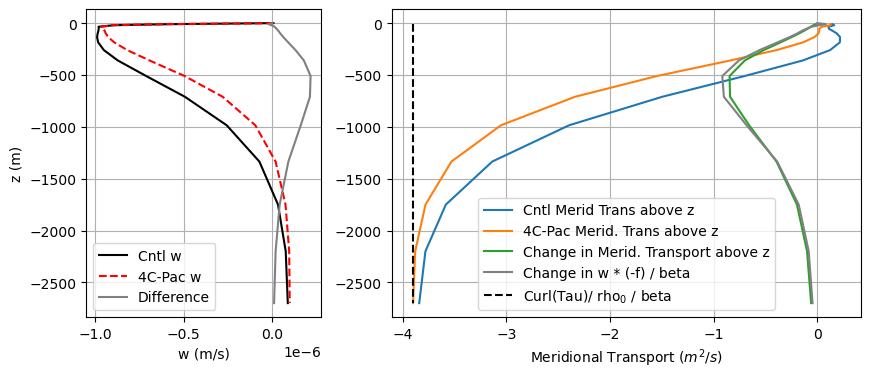

In [664]:

# Create figure and subplots with gridspec to control width ratios
fig = plt.figure(figsize=(10, 4))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])  # Left is twice as wide

# Left subplot (wider)
ax1 = fig.add_subplot(gs[0])
#ax1.plot(x, y1, label='sin(x)', color='blue')
#ax1.set_title('Wider Plot')
#ax1.legend()

xran2 = np.arange(65,80)
yran2 = np.arange(40,48)
zran2 = np.arange(0,17)
zranw = np.arange(0,18)


#PlA = wvSO.isel( XC = xran, YC = yran, Zl= zran).mean('XC').mean('YC')
PlB = wvPac.isel(  XC = xran2, YC = yran2, Zl= zranw).mean('XC').mean('YC')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = wvcon.isel( XC = xran2, YC = yran2, Zl= zranw).mean('XC').mean('YC')

ax1.plot(Pl0, wvPac.Zl[zranw], 'k')
ax1.plot(PlB, wvPac.Zl[zranw], 'r--')
ax1.plot(PlB - Pl0, wvPac.Zl[zranw], 'gray')

ax1.legend(['Cntl w', '4C-Pac w', 'Difference'])
ax1.grid()
ax1.set_ylabel('z (m)')
ax1.set_xlabel('w (m/s)')

# Right subplot (narrower)
ax2 = fig.add_subplot(gs[1])
ax2.plot(np.cumsum(vtr0), PacTr.Zu[zran2])
ax2.plot(np.cumsum(vtrP), PacTr.Zu[zran2])
ax2.plot(np.cumsum(vtrP) - np.cumsum(vtr0), PacTr.Zu[zran2])


wdif = PlB-Pl0
#wprofP = -wvPac.isel(XC = xran2, YC = yran2, Zl= zran2).mean('XC').mean('YC') 
#wPl2 = (wprofP - wprofP[3])/np.mean(beta)*np.mean(f) 
ax2.plot(-wdif/np.mean(beta)*np.mean(f), wvPac.Zl[zranw], 'gray')

ax2.plot(0*PacTr.Zu[zran2] + mycurl/1035/beta, PacTr.Zu[zran2], 'k--')
#plt.plot(wPl2 , wvPac.Zl[zran2], 'red')
ax2.legend(['Cntl Merid Trans above z', '4C-Pac Merid. Trans above z', 'Change in Merid. Transport above z', 'Change in w * (-f) / beta', 'Curl(Tau)/ rho$_0$ / beta'])
ax2.grid()
ax2.set_xlabel('Meridional Transport $(m^2/s)$')

# plt.savefig('eps_figures/profiles7-19.eps')

In [ ]:
# I should check if this h scheme works at all. Maybe another day ... 

## now retry with Sverdrup transport!

In [215]:
xran2 = np.arange(50,90)
yran2 = np.arange(34,55)
zran2 = np.arange(0,23)

zran2 = range(23)
PlB = vvPac.isel(  XC = xran2, YG = yran2, Z= zran2)
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = vvcon.isel( XC = xran2, YG = yran2, Z= zran2)

vtr0  = Pl0  * PacTr.drF[zran2]#* PacTr.hFacS.isel( XC = xran2, YG = yran2, Z= zran2)
vtrP  = PlB  * PacTr.drF[zran2]#* PacTr.hFacS.isel( XC = xran2, YG = yran2, Z= zran2)

SverC = np.cumsum(vtr0,0)
SverP = np.cumsum(vtrP,0)


In [216]:
## Now we're getting the sverdrup transport implied by wind stress curl 
# Note that it might not be perfectly matched because it's center vs. southern border. Will just try it. 
#xran2 = np.arange(45,100)
#yran2 = np.arange(35,56)
#zran2 = np.arange(0,17)
# this 
tauxd = taux[np.ix_(yran2-1, xran2)]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2-1)) -taux[np.ix_(yran2+1, xran2)]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2+1))

tauyd = tauy[np.ix_(yran2, xran2+1)]*np.array(SOTr.dyC.isel(XC = xran2+1, YG = yran2)) - tauy[np.ix_(yran2, xran2-1)]*np.array(SOTr.dyC.isel(XC = xran2-1, YG = yran2))

mycurl = (tauxd+tauyd) / np.array(SOTr.rA.isel(XC = xran2, YC = yran2)) / 2

beta= 2*np.cos(np.array(SOTr.YC[yran2]/180) * np.pi)/6370000 * 7.3e-5
a = np.transpose(np.tile(beta, [len(xran2),1]))

#fcor = 2*np.sin(np.array(SOTr.YC[yran2]/180) * np.pi)* 7.3e-5
#a = np.transpose(np.tile(fcor, [len(xran2),1]))

test = mycurl/1035 / a

In [258]:
(taux[np.ix_(yran2-1, xran2)]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2-1))).shape

(8, 15)

In [395]:
np.array(SverC[:, 3,15])

array([ 0.28102553,  0.29427698,  0.18887295,  0.06312937, -0.0099742 ,
       -0.0729726 , -0.16313592, -0.31644255, -0.6378464 , -1.2206824 ,
       -2.2204435 , -3.412411  , -4.5862994 , -5.4570885 , -5.916976  ,
       -6.112861  , -6.229903  , -6.2983103 , -6.3152523 , -6.2798376 ,
       -6.2005825 , -6.091514  , -6.091514  ], dtype=float32)

In [379]:
np.array(test[3,15])

array(-6.08459433)

In [378]:
np.array(np.nansum(vtr0[:,3,15]))

array(-6.091514, dtype=float32)

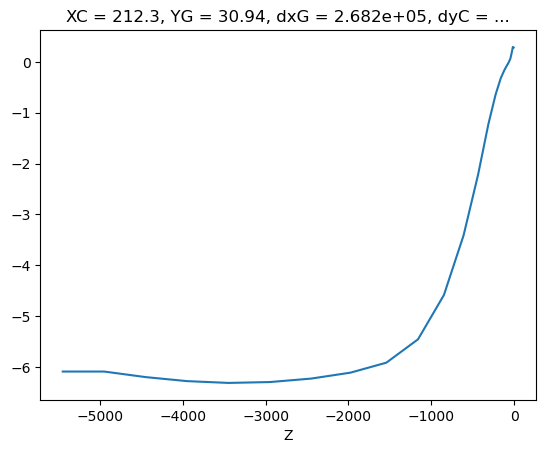

In [386]:
SverC[:,3,15].plot()

In [217]:
## here's GPT's proposal for how this could work ... 
def interpolate_depth_at_temp(depth, temp, target_temp):
    # Find all sign changes in (temp - target_temp)
    diff = temp - target_temp
    sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]

    if len(sign_change) == 0:
        # No crossing: fallback to closest match
        idx = np.argmin(np.abs(diff))
        return depth[idx], False  # second output says: not interpolated

    # Take first crossing (or choose based on preference)
    i = sign_change[-1]
    # Linear interpolation: (x0, y0) and (x1, y1)
    x0, x1 = depth[i], depth[i+1]
    y0, y1 = temp[i], temp[i+1]

    # Avoid division by zero
    if y1 == y0:
        return x0, False

    # Linear interpolation for depth
    depth_interp = x0 + (target_temp - y0) * (x1 - x0) / (y1 - y0)
    return depth_interp, True

# Example usage
#depth_at_interp, is_interpolated = interpolate_depth_at_temp(depth_profile, temp_profile, target_temp)
#print(f"Interpolated depth: {depth_at_interp} m")


In [399]:
np.array(interpolate_depth_at_temp(PacTr.Zu, SverC[:,3,15], test[3,15]/2))

array([-647.8987,    1.    ], dtype=float32)

In [393]:
PacTr.Zu

<xarray.DataArray 'Zu' (Zu: 23)> Size: 92B
array([  -10.,   -20.,   -35.,   -55.,   -75.,  -100.,  -135.,  -185.,  -260.,
        -360.,  -510.,  -710.,  -985., -1335., -1750., -2200., -2700., -3200.,
       -3700., -4200., -4700., -5200., -5700.], dtype='>f4')
Coordinates:
  * Zu       (Zu) >f4 92B -10.0 -20.0 -35.0 -55.0 ... -4.7e+03 -5.2e+03 -5.7e+03
Attributes:
    standard_name:      depth_at_upper_w_location
    long_name:          vertical coordinate of upper cell interface
    units:              m
    positive:           down
    axis:               Z
    c_grid_axis_shift:  0.5

In [218]:
def interpolate_depth_at_temp(depth, temp_profile, target_temp):
    diff = temp_profile - target_temp
    sign_change = np.where(np.diff(np.sign(diff)) != 0)[0]

    if len(sign_change) == 0:
        idx = np.argmin(np.abs(diff))
        return depth[idx], False  # fallback: closest match

    #i = sign_change[-1] # choosing the deepest crossover.
    i = sign_change[0] # choosing the shallowest crossover!
    x0, x1 = depth[i], depth[i+1]
    y0, y1 = temp_profile[i], temp_profile[i+1]

    if y1 == y0:
        return x0, False

    depth_interp = x0 + (target_temp - y0) * (x1 - x0) / (y1 - y0)
    return depth_interp, True

# Main driver for 3D array
def depth_at_target_temp_3d(temp, depth, target_temp):
    nz, ny, nx = temp.shape
    result = np.full((ny, nx), np.nan)   # initialize output
    mask_interp = np.zeros((ny, nx), dtype=bool)  # optional: tracks where it was interpolated

    for j in range(ny):
        for i in range(nx):
            temp_profile = temp[:, j, i]
            if np.any(np.isfinite(temp_profile)):
                z_val, was_interp = interpolate_depth_at_temp(depth, temp_profile, target_temp[j,i])
                result[j, i] = z_val
                mask_interp[j, i] = was_interp

    return result, mask_interp

# Example usage
# temp.shape = (depth, lat, lon), depth.shape = (depth,)
# target_temp = 13.0
#depths_at_13C, mask = depth_at_target_temp_3d(temp, depth, 13.0)


In [219]:
results = depth_at_target_temp_3d(np.array(SverC), np.array(PacTr.Zu), test/2)
resultsPac = depth_at_target_temp_3d(np.array(SverP), np.array(PacTr.Zu), test/2)

In [448]:
resultsPac[1]

array([[False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True, False, False, False,
        False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True],
       [ True,  True,  True,  True,  True,  True,  True, False, False,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
        False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False, False],
       [ True,  True,  True,  True,  

In [400]:
test.shape

(10, 30)

/glade/derecho/scratch/bataylor/tmp/ipykernel_33056/3880103631.py:2: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


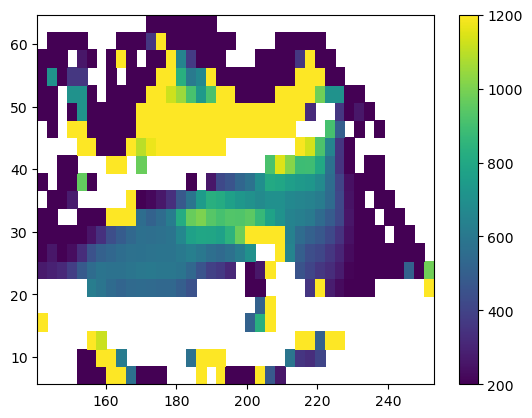

In [443]:
plt.pcolor(PacTr.XC[xran2], PacTr.YC[yran2], -np.where(np.abs(test)<2, np.nan, results[0]), vmin = 200, vmax = 1200)
plt.colorbar()

/glade/derecho/scratch/bataylor/tmp/ipykernel_1846/4290784703.py:7: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(A, ax=ax, shrink=0.5)


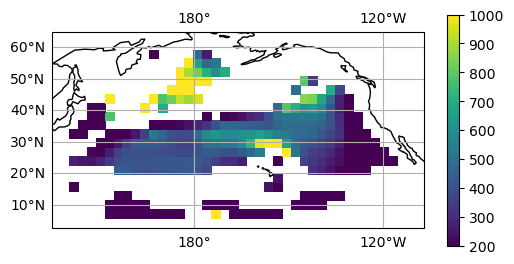

In [231]:
import cartopy.crs as ccrs

proj = ccrs.PlateCarree(central_longitude=180)
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': proj})
A = ax.pcolor(PacTr.XC[xran2], PacTr.YC[yran2], -hPacv, vmin = 200, vmax = 1000, transform = ccrs.PlateCarree())
ax.gridlines()
plt.colorbar(A, ax=ax, shrink=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5)
ax.coastlines()

In [221]:
# so this seems fine. I'm assuming the ratio is also good? 
#hPacv = np.where(np.abs(test)<1 | ~(resultsPac[1]), np.nan, resultsPac[0])
hPacv = np.where( ~(resultsPac[1]), np.nan, resultsPac[0]) # strict, but these are the good values...
hPacv = np.where( np.abs(test)<2, np.nan, hPacv)
hv = np.where(np.abs(test)<1, np.nan, results[0])

/glade/derecho/scratch/bataylor/tmp/ipykernel_1846/2175331925.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(B, ax=ax, shrink = 0.5)


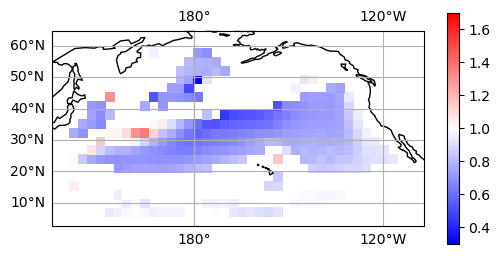

In [232]:
import cartopy.crs as ccrs

proj = ccrs.PlateCarree(central_longitude=180)
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': proj})

B = ax.pcolor(PacTr.XC[xran2], PacTr.YC[yran2], hPacv/hv, vmin = 0.3, vmax = 1.7, cmap='bwr', transform = ccrs.PlateCarree())
ax.gridlines()
plt.colorbar(B, ax=ax, shrink = 0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.5)
ax.coastlines()

In [ ]:
# that's quite clean in the downwelling and upwelling regions.
# might be a bit interesting to see what it looks like in the central subpolar north pacific... 
# Also I think Sverdrup is slightly more defensible.. 

/glade/derecho/scratch/bataylor/tmp/ipykernel_33056/313428038.py:2: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


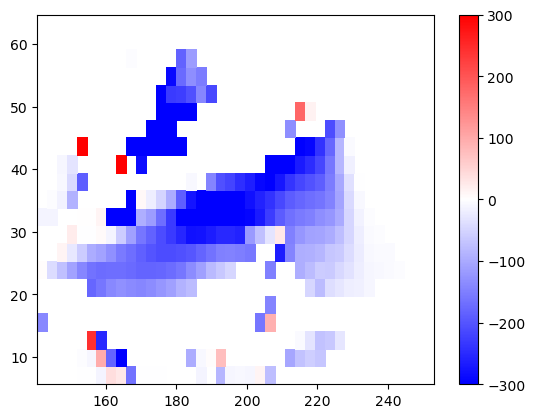

In [458]:
plt.pcolor(PacTr.XC[xran2], PacTr.YC[yran2], -hPacv+hv, vmin = -300, vmax = 300, cmap='bwr')
plt.colorbar()

## Overturning streamfunction, subtropical cell 

Here's where I want to demonstrate how w and v look different. 

In [167]:
## initial thought: quiver plot with w and v 

#import xarray as xr
#import matplotlib.pyplot as plt
#import numpy as np

# --- Compute differences ---
delta_w = wvPac - wvcon
delta_v = vvPac - vvcon
delta_v = delta_v.mean('time')

# Optional: average along longitude if 3D

delta_w = delta_w.mean(dim='XC')
delta_v = delta_v.mean(dim='XC')

# Subsample to avoid clutter
lat = delta_w['YC'].values
depth = delta_w['Zl'].values

lat_sub = YC[::2]         # every 4th lat
depth_sub = Z[::2]     # every 2nd depth

# Subsample velocity fields
W = delta_w.sel(YC=lat_sub, Zl=depth_sub)
V = delta_v.sel(YC=lat_sub, Zl=depth_sub)

LAT, DEPTH = np.meshgrid(lat_sub, depth_sub)

# Convert depth to positive-down if needed
DEPTH = -DEPTH

# --- Plot ---
plt.figure(figsize=(10, 6))
plt.quiver(
    LAT, DEPTH,             # horizontal: lat, vertical: depth
    V.values.T, W.values.T, # meridional and vertical diffs
    scale=1e-5, angles='xy'
)
plt.gca().invert_yaxis()
plt.xlabel('Latitude')
plt.ylabel('Depth (m)')
plt.title('Change in Meridional and Vertical Velocity (Δv, Δw)')
plt.grid(True)
plt.tight_layout()
plt.show()


ValueError: 'time' not found in array dimensions ('Z', 'YG', 'XC')

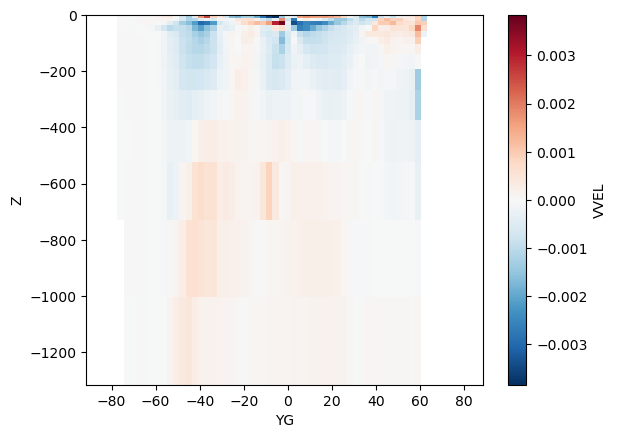

In [183]:
Δv_xsec.isel(Z=range(14)).plot()

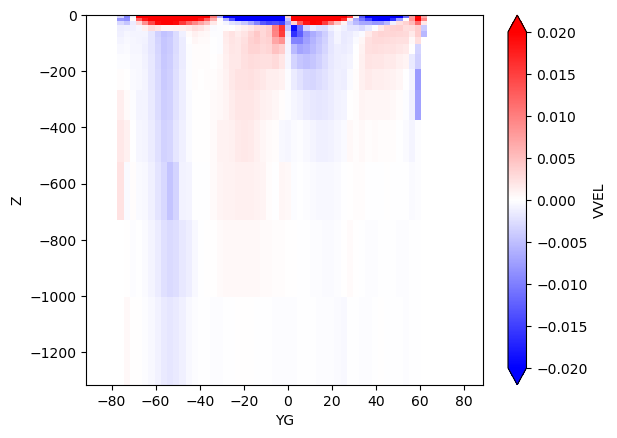

In [184]:
vvcon.mean('time').isel(Z=range(14)).isel(XC = XC_sel).mean('XC').plot(vmin = -0.02, vmax = 0.02, cmap = 'bwr')

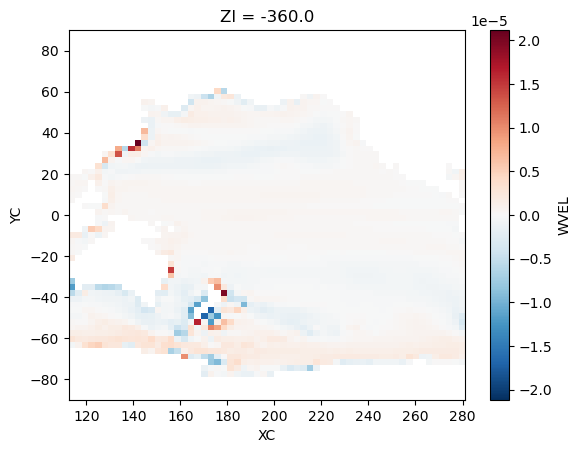

In [185]:
wvPac.isel(Zl = 10, XC = range(40,100)).plot()

In [179]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Compute difference
Δw = wvPac - wvcon   # dims: XC, YC, Zl
Δv = vvPac - vvcon   # dims: XC, YC, Z
Δv = Δv.mean('time')

# Pick a fixed XC slice or average over XC
# e.g., slice at XC = specific index or value
XC_sel = np.arange(40,100)  # or any lon value
Δw_xsec = Δw.isel(XC=XC_sel).mean(dim='XC')
Δv_xsec = Δv.isel(XC = XC_sel).mean(dim='XC')

# We need to align vertical depths: Zl vs Z
# Interpolate one onto the other, e.g., Δw onto Δv's Z grid

Δv_xsec.coords['YG'] = Δv_xsec.YG
Δv_interp = Δv_xsec.interp(YG= np.arange(50))
Δv_interp = Δv_interp.rename({'YG': 'YC'})

#Δw_2d = Δw_2d.rename({'Zl': 'Z'})  # rename to match dimension
#Z_native = Δv_2d.Z.values.astype('<f8')
#Δw_on_Z = Δw_2d.interp(Z=Z_native)

# --- Step 4: Interpolate Δw from Zl to Z ---
Δw_interp = Δw_xsec.interp(Zl=Δv_interp.Z)
Δw_interp = Δw_interp.rename({'Zl': 'Z'})

# --- Step 5: Subsample for plotting ---
lat = Δw_interp.YC.values
depth = Δw_interp.Z.values

lat_sub = lat[::4]
depth_sub = depth[::2]

W = Δw_interp.sel(YC=lat_sub, Z=depth_sub).values.T
V = Δv_interp.sel(YC=lat_sub, Z=depth_sub).values.T
LAT, DEP = np.meshgrid(lat_sub, depth_sub)

#DEP = -DEP  # plot depth positive downward

# --- Step 6: Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
q = ax.quiver(
    LAT, DEP,
    V, W,
    scale=1e-5, angles='xy', scale_units='xy',
    pivot='middle', width=0.003
)

ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Depth (m)")
ax.set_title(f"Δv (meridional) & Δw (vertical) at XC = {XC_sel}")
ax.grid(True)

# Add a quiver key
ax.quiverkey(q, X=0.9, Y=1.02, U=1e-5, label='1e-5 m/s', labelpos='E')

plt.tight_layout()
plt.show()


ValueError: Big-endian buffer not supported on little-endian compiler

In [145]:
ds = xr.Dataset({
    'V': Δv_2d,
    'W': Δw_on_Z
})
fig, ax = plt.subplots(figsize=(8,6))
ds.plot.quiver(
    x='YC', y='Z',
    u='V', v='W',
    ax=ax,
    scale=1e-5, add_guide=False,
    width=0.003, pivot='middle'
)
ax.invert_yaxis()
ax.set_xlabel("Latitude")
ax.set_ylabel("Depth")
plt.title("Δv & Δw via xarray")


NameError: name 'Δw_on_Z' is not defined

In [ ]:
# my hypothesis for why this is funky is that v is also on YG coordinates. They don't play well together. 
# perhaps this is a big issue 
# it's still not solved! 

# should I keep working with this? this is frustrating! I am doing something very simple ..

In [ ]:
# can I just make something simple with

for x in range(128):
    for y in range(64):
        if gNew[y,x]>0:
            tracNew[:gNew[y,x], y, x] =np.interp(-ZNew[:g23[y,x]], -ZOld[:g15[y,x]], tracOld[:g15[y,x],y,x])
# is this wrong, seems like g23 and g15 aren't defined?
return tracNew

## isopycnal slope and velocity ... 

In [ ]:
# I want to do two calculations! 
# first, the density, and then the slope. 



In [190]:
fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
fol4 = '/glade/derecho/scratch/bataylor/23layer_YT/4CPac_try2/'
folSO = '/glade/derecho/scratch/bataylor/23layer_YT/4CSO_try2/'
fol0 = '/glade/derecho/scratch/bataylor/23layer_YT/control/'

PacTS = xmitgcm.open_mdsdataset(fol4, grid_dir = fol3, prefix = 'Diag3d', iters = myIts.tolist(), ignore_unknown_vars = True)
vol = PacTr.drF*PacTr.hFacC*PacTr.rA
SOTS = xmitgcm.open_mdsdataset(folSO, grid_dir = fol3, prefix = ['Diag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)
CtlTS = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['Diag3d'], iters = myIts.tolist(), ignore_unknown_vars = True)

In [193]:
SaSO = xr.where(SOTS.SALT ==0, np.nan, SOTS.SALT).mean('time')
TeSO= xr.where(SOTS.SALT ==0, np.nan, SOTS.THETA).mean('time')
SaPac = xr.where(PacTS.SALT ==0, np.nan, PacTS.SALT).mean('time')
TePac= xr.where(PacTS.SALT ==0, np.nan, PacTS.THETA).mean('time')
Sacon= xr.where(CtlTS.SALT ==0, np.nan, CtlTS.SALT).mean('time')
Tecon= xr.where(CtlTS.SALT ==0, np.nan, CtlTS.THETA).mean('time')

In [511]:
sigcon = gsw.sigma0(Sacon, Tecon)
sigPac = gsw.sigma0(SaPac, TePac)

In [512]:
# Ok starting from the simplest case. 
# let's do one spot in the water column, between YC = 45 and 46 and XC = 72

# I think I can use xgcm for this pretty much. 

myX = np.arange(65,85) 
ylow = np.arange(5,53)
myV = vvcon.isel(YG = ylow+1, XC =myX).mean('time').mean('XC').mean('YG')
wsouth = (np.array( wvcon.isel(Zl = range(22), YC = ylow, XC =myX)) +np.array( wvcon.isel(Zl = range(1,23), YC = ylow, XC =myX)))/2
wnorth = (np.array( wvcon.isel(Zl = range(22), YC = ylow+1, XC =myX)) +np.array( wvcon.isel(Zl = range(1,23), YC = ylow+1, XC =myX)))/2
myW = (wsouth+wnorth)/2
myW = np.nanmean(np.nanmean(myW,2),1)# only 22 long. 

sigsouth = np.array(sigcon.isel(XC = myX, YC = ylow))
signorth = np.array(sigcon.isel(XC = myX, YC = ylow+1))

sigPsouth = np.array(sigPac.isel(XC = myX, YC = ylow))
sigPnorth = np.array(sigPac.isel(XC = myX, YC = ylow+1))



/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/371927290.py:12: RuntimeWarning: Mean of empty slice
  myW = np.nanmean(np.nanmean(myW,2),1)# only 22 long.


In [380]:
Tecon.XC[myX]

<xarray.DataArray 'XC' (XC: 1)> Size: 4B
array([184.21875], dtype='>f4')
Coordinates:
  * XC       (XC) >f4 4B 184.2

In [419]:
# i think this is an incomplete code, use the one below?

#znorth = np.zeros([len(myX), len(ylow)])
#znorth[j,i] = np.interp(sigsouth, signorth, vvcon.Z)
dz = znorth - np.array(vvcon.Z)
dy = 111*45/16
isoslope = dz/dy
velslope = myW*1000/myV.isel(Z=range(22))
plt.plot(isoslope, vvcon.Z)
plt.plot(velslope, vvcon.Z.isel(Z=range(22)))

ValueError: object too deep for desired array

In [420]:
znorth = np.zeros([23,len(ylow),len(myX),])
for i in range(len(myX)):
    for j in range(len(ylow)):
        znorth[:,j,i] = np.interp(sigsouth[:,j,i], signorth[:,j,i], vvcon.Z)
dz = znorth - np.tile(np.reshape(np.array(vvcon.Z),[23,1,1]), [1, len(ylow), len(myX)])
dy = 111*45/16
isoslope = np.nanmean(np.nanmean(dz,2),1)/dy
#velslope = myW*1000/myV.isel(Z=range(22))


znorthP = np.zeros([23,len(ylow),len(myX),])
for i in range(len(myX)):
    for j in range(len(ylow)):
        znorthP[:,j,i] = np.interp(sigPsouth[:,j,i], sigPnorth[:,j,i], vvcon.Z)
dzP = znorthP - np.tile(np.reshape(np.array(vvcon.Z),[23,1,1]), [1, len(ylow), len(myX)])

#plt.plot(isoslope, vvcon.Z)
#plt.plot(velslope, vvcon.Z.isel(Z=range(22)))
#plt.xlim([-1,1])
#plt.ylim([-2000,0])
#plt.title(str(np.array(vvcon.YG.isel(YG = ylow+1))))
#plt.grid()

/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/892956991.py:7: RuntimeWarning: Mean of empty slice
  isoslope = np.nanmean(np.nanmean(dz,2),1)/dy


In [ ]:
# clearly this does not work! 
# coudl be because there is some bolus velocity as well that should be added to w? 
# could be because it's too noisy ...'


# I do think the results for the isopycnal slope are reasonable ... 
# but the ratio of velocities is wildly difficult to deal with. 
# I wonder if there's a way to make this more reasonable ... 

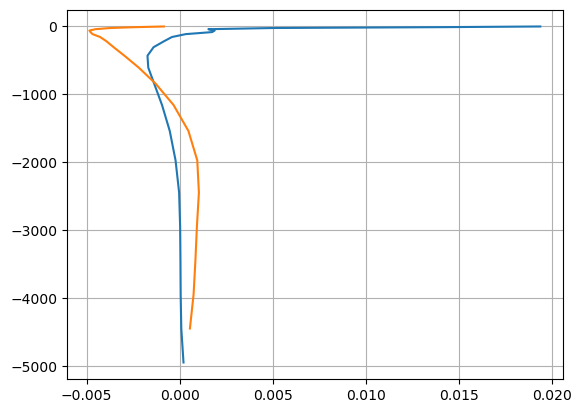

In [421]:
plt.plot(myV, vvcon.Z)
plt.plot(myW*10000, vvcon.Z.isel(Z=range(22)))
plt.grid()

/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/1250066618.py:3: RuntimeWarning: Mean of empty slice
  isoslopeCtl = np.nanmean(np.array(dz),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/1250066618.py:5: RuntimeWarning: Mean of empty slice
  isoslopePac = np.nanmean(np.array(dzP),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/1250066618.py:9: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


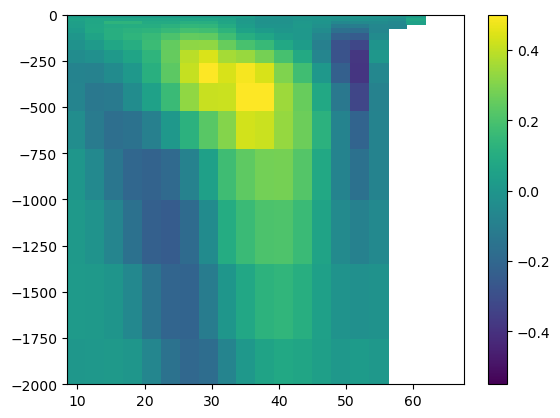

In [274]:
# OK maybe just some plots of isopycnal slopes ... 

isoslopeCtl = np.nanmean(np.array(dz),2)/dy

isoslopePac = np.nanmean(np.array(dzP),2)/dy
vm = -0.5
plt.pcolor(PacTS.YC[ylow], PacTS.Z, isoslopeCtl, vmin = -vm, vmax = vm)
plt.ylim([-2000,0])
plt.colorbar()



In [429]:
Tecon.XC[65:80]

<xarray.DataArray 'XC' (XC: 15)> Size: 60B
array([184.21875, 187.03125, 189.84375, 192.65625, 195.46875, 198.28125,
       201.09375, 203.90625, 206.71875, 209.53125, 212.34375, 215.15625,
       217.96875, 220.78125, 223.59375], dtype='>f4')
Coordinates:
  * XC       (XC) >f4 60B 184.2 187.0 189.8 192.7 ... 215.2 218.0 220.8 223.6

/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/152940789.py:3: RuntimeWarning: Mean of empty slice
  isoslopeCtl = np.nanmean(np.array(dz),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/152940789.py:5: RuntimeWarning: Mean of empty slice
  isoslopePac = np.nanmean(np.array(dzP),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/152940789.py:9: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


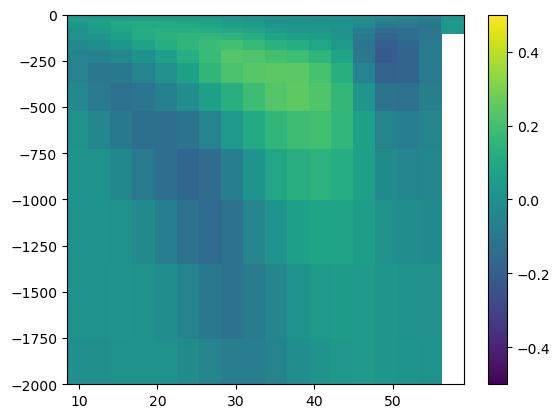

In [422]:
# OK maybe just some plots of isopycnal slopes ... 

isoslopeCtl = np.nanmean(np.array(dz),2)/dy

isoslopePac = np.nanmean(np.array(dzP),2)/dy
vm =0.5
plt.pcolor(PacTS.YC[ylow], PacTS.Z, isoslopePac, vmin = -vm, vmax = vm)
plt.ylim([-2000,0])
plt.colorbar()



/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2273854443.py:3: RuntimeWarning: Mean of empty slice
  isoslopeCtl = np.nanmean(np.array(dz),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2273854443.py:5: RuntimeWarning: Mean of empty slice
  isoslopePac = np.nanmean(np.array(dzP),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2273854443.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(A)


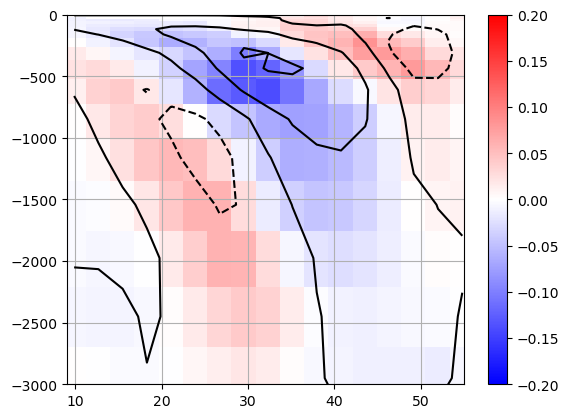

In [425]:
# OK maybe just some plots of isopycnal slopes ... 

isoslopeCtl = np.nanmean(np.array(dz),2)/dy

isoslopePac = np.nanmean(np.array(dzP),2)/dy
vm =0.2
A = plt.pcolor(PacTS.YC[ylow], PacTS.Z, isoslopePac - isoslopeCtl, vmin = -vm, vmax = vm, cmap = 'bwr')
plt.colorbar(A)
plt.contour(PacTS.YC[ylow], PacTS.Z, isoslopeCtl, vmin = -vm, vmax = vm, levels = [-0.3, -0.15, 0, 0.15 ,0.3], colors='k')
plt.ylim([-3000,0])
plt.xlim([9,55])
plt.grid()





/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2298222027.py:3: RuntimeWarning: Mean of empty slice
  isoslopeCtl = np.nanmean(np.array(dz),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2298222027.py:5: RuntimeWarning: Mean of empty slice
  isoslopePac = np.nanmean(np.array(dzP),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2298222027.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(A)


(-3000.0, 0.0)

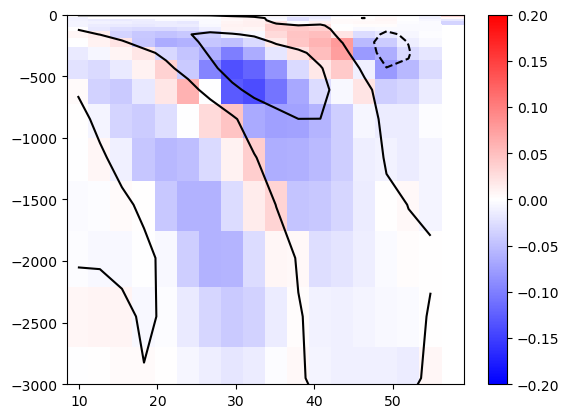

In [424]:
# abs value of  slope change
isoslopeCtl = np.nanmean(np.array(dz),2)/dy

isoslopePac = np.nanmean(np.array(dzP),2)/dy
vm =0.2
A = plt.pcolor(PacTS.YC[ylow], PacTS.Z, np.abs(isoslopePac) - np.abs(isoslopeCtl), vmin = -vm, vmax = vm, cmap = 'bwr')
plt.colorbar(A)
plt.contour(PacTS.YC[ylow], PacTS.Z, isoslopeCtl, vmin = -vm, vmax = vm, levels = [-0.4, -0.2, 0, 0.2 ,0.4], colors='k')
plt.ylim([-3000,0])





/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2062462576.py:3: RuntimeWarning: Mean of empty slice
  isoslopeCtl = np.nanmean(np.array(dz),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2062462576.py:5: RuntimeWarning: Mean of empty slice
  isoslopePac = np.nanmean(np.array(dzP),2)/dy
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2062462576.py:7: RuntimeWarning: invalid value encountered in divide
  A = plt.pcolor(PacTS.YC[ylow], PacTS.Z, isoslopePac/ isoslopeCtl, vmin = -vm+2, vmax = vm, cmap = 'bwr')
/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/2062462576.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(A)


(-3000.0, 0.0)

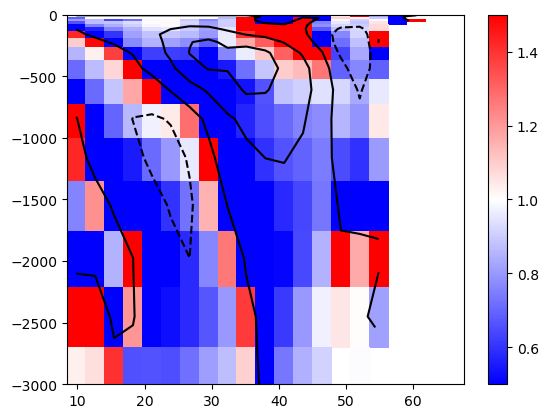

In [286]:
# OK maybe just some plots of isopycnal slopes ... 

isoslopeCtl = np.nanmean(np.array(dz),2)/dy

isoslopePac = np.nanmean(np.array(dzP),2)/dy
vm =1.5
A = plt.pcolor(PacTS.YC[ylow], PacTS.Z, isoslopePac/ isoslopeCtl, vmin = -vm+2, vmax = vm, cmap = 'bwr')
plt.colorbar(A)
plt.contour(PacTS.YC[ylow], PacTS.Z, isoslopeCtl, vmin = -vm, vmax = vm, levels = [-0.4, -0.2, 0, 0.2 ,0.4], colors='k')
plt.ylim([-3000,0])





In [40]:
myV.shape

myV_YC = (np.array(vvcon.isel(YG = ylow+1, XC =myX).mean('XC')) + np.array(vvcon.isel(YG = ylow, XC =myX).mean('XC')))/2

myV_YCpac = (myVpac + np.array(vvPac.isel(YG = ylow, XC =myX).mean('XC')))/2

In [47]:
## here we're going to do something very simple! 
# it's to look at how the magnitude of velocities are actually changing ... 
# we know that the vertical integral is the same for v. (Is that also the same for u?) 
# first thing is just get the total magnitude of velocity to be output. 

ylow = np.arange(20,53)
myX = np.arange(64,80) # could consider 60 to 80 ...  

#uvSO = xr.where(SOTr.UVEL ==0, np.nan, SOTr.UVEL).mean('time')
#ageSO= xr.where(SOTr.TRAC01 ==0, np.nan, SOTr.TRAC11).mean('time')
#uvPac = xr.where(PacTr.UVEL ==0, np.nan, PacTr.UVEL).mean('time')
#agePac= xr.where(PacTr.TRAC11 ==0, np.nan, PacTr.TRAC11).mean('time')
#uvcon= xr.where(CtlTr.UVEL ==0, np.nan, CtlTr.UVEL).mean('time')
#agecon= xr.where(CtlTr.TRAC11 ==0, np.nan, CtlTr.TRAC11).mean('time')


# clearly this should be interpolate on the same coordinates for the speed dif. It's silly that I wouldn't do this - though I'm fine to plot v separately. 
# actually I should definitely take the speed first, then do the zonal mean, then subtract! Whoops! Good call...

myV = np.array(vvcon.isel(YG = ylow+1, XC =myX).mean('XC'))
myU = np.array(uvcon.isel(YC = ylow, XG =myX).mean('XG'))
mySpeed = ((np.array(vvcon.isel(YG = ylow+1, XC =myX)) + np.array(vvcon.isel(YG = ylow, XC =myX)))**2)/4 + \
           (np.array(uvcon.isel(YC = ylow, XG =myX)) + np.array(uvcon.isel(YC = ylow, XG =myX+1)))**2 /4
mySp = np.nanmean(mySpeed**0.5,2)

myVpac = np.array(vvPac.isel(YG = ylow+1, XC =myX).mean('XC'))
myUpac = np.array(uvPac.isel(YC = ylow, XG =myX).mean('XG'))

mySpeed = ((np.array(vvPac.isel(YG = ylow+1, XC =myX)) + np.array(vvPac.isel(YG = ylow, XC =myX)))**2)/4 + \
           (np.array(uvPac.isel(YC = ylow, XG =myX)) + np.array(uvPac.isel(YC = ylow, XG =myX+1)))**2 /4
mySpPac = np.nanmean(mySpeed**0.5,2)

#myV_YC = (np.array(vvcon.isel(YG = ylow+1, XC =myX).mean('XC')) + np.array(vvcon.isel(YG = ylow, XC =myX).mean('XC')))/2
#myV_YCpac = (myVpac + np.array(vvPac.isel(YG = ylow, XC =myX).mean('XC')))/2


speeddif = mySpPac- mySp
#speeddif = (myV_YCpac**2 + myUpac**2)**0.5 - (myV_YC**2 + myU**2)**0.5 

/glade/derecho/scratch/bataylor/tmp/ipykernel_62263/3244461761.py:24: RuntimeWarning: Mean of empty slice
  mySp = np.nanmean(mySpeed**0.5,2)
/glade/derecho/scratch/bataylor/tmp/ipykernel_62263/3244461761.py:31: RuntimeWarning: Mean of empty slice
  mySpPac = np.nanmean(mySpeed**0.5,2)


/glade/derecho/scratch/bataylor/tmp/ipykernel_1846/3946921336.py:2: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


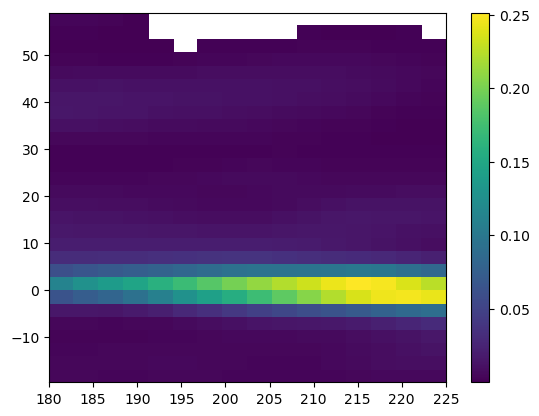

In [82]:
plt.pcolor(PacTr.XC[myX] , PacTr.YC[ylow], mySpeed[0,:,:])
plt.colorbar()

In [84]:
speeddif.shape

(23, 28)

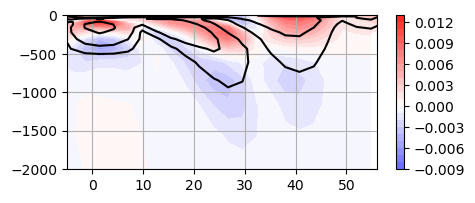

In [48]:
plt.figure(figsize =[5,2])
# my one concern for this figure is that I should interpolate the V's onto the Y axis ultimately. 
    
vm = 0.015
plt.contourf(PacTr.YC[ylow], PacTr.Z, speeddif, vmin =-vm, vmax = vm,levels = 20, cmap = 'bwr')
plt.colorbar()
plt.contour(PacTr.YC[ylow], PacTr.Z,mySp, levels = [0.01,0.02, 0.05, 0.1,],colors = 'k')

plt.ylim([-2000,0])
plt.xlim([-5,56])
plt.grid()

/glade/derecho/scratch/bataylor/tmp/ipykernel_16506/758367680.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


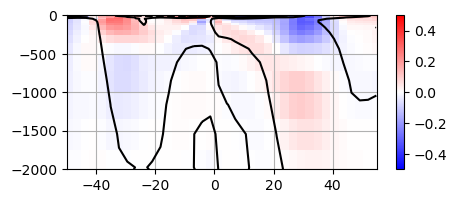

In [505]:
plt.figure(figsize =[5,2])

vm = 0.5
plt.pcolor(PacTS.YC[ylow], PacTS.Z,100*(myVpac-myV) , vmin =-vm, vmax = vm, cmap = 'bwr')
plt.colorbar()
plt.contour(PacTS.YC[ylow], PacTS.Z,(myV), colors = 'k')

plt.ylim([-2000,0])
plt.xlim([-50,55])
plt.grid()

/glade/derecho/scratch/bataylor/tmp/ipykernel_1846/1145137839.py:9: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


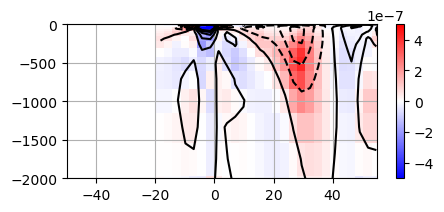

In [86]:
vm = 0.0000005

plt.figure(figsize =[5,2])

myWpac = np.array(wvPac.isel(YC = ylow+1, XC =myX).mean('XC'))
myW = np.array(wvcon.isel(YC = ylow+1, XC =myX).mean('XC'))

plt.pcolor(PacTS.YC[ylow], PacTS.Zl,myWpac-myW , vmin =-vm, vmax = vm, cmap = 'bwr')
plt.colorbar()
plt.contour(PacTS.YC[ylow], PacTS.Zl,(myW), levels = np.arange(-3e-6,3e-6, 5e-7),colors = 'k')

plt.ylim([-2000,0])
plt.xlim([-50,55])
plt.grid()



In [50]:
sigcon = gsw.sigma0(Sacon, THcon)
sigPac = gsw.sigma0(SaPac, THPac)

/glade/derecho/scratch/bataylor/tmp/ipykernel_62263/2647048021.py:18: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


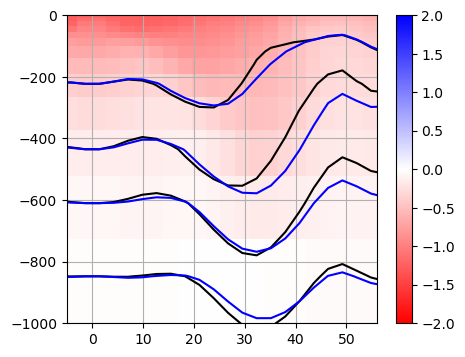

In [51]:
# very simple figure just showing density change and new and old isopycnals. 
#myX = range(65,76)
#ylow = np.arange(5,53)

plt.figure(figsize =[5,4])
sigsouth =sigcon.isel(XC = myX, YC = ylow).mean('XC')
#signorth =sigcon.isel(XC = myX, YC = ylow+1)
sigPsouth = sigPac.isel(XC = myX, YC = ylow).mean('XC')
#sigPnorth = sigPac.isel(XC = myX, YC = ylow+1)

# OK finish this up real quick.
# pick a few contour levels that I want 
y30 = 12
siglevs = [sigsouth[8,y30],sigsouth[10, y30], sigsouth[11,y30], sigsouth[12,y30]] 
sigPlevs = [sigPsouth[8,y30], sigPsouth[10, y30], sigPsouth[11,y30], sigPsouth[12,y30]] 

plt.pcolor(PacTS.YC[ylow], PacTS.Z, sigPsouth - sigsouth, vmin = -2, vmax =2,cmap = 'bwr_r')
plt.colorbar()
plt.contour(PacTS.YC[ylow], PacTS.Z, sigsouth, colors = 'k', levels = siglevs)
plt.contour(PacTS.YC[ylow], PacTS.Z, sigPsouth, colors = 'blue', levels = sigPlevs)

plt.ylim([-1000,0])
plt.xlim([-5,56])
plt.grid()




In [ ]:
## takeaways: isopycnal slope is very different in the subtropics, more similar elsewhere .. cool. 

/glade/derecho/scratch/bataylor/tmp/ipykernel_1846/406911356.py:52: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(I, ax= axs[1,1])


Text(0.5, 1.0, 'Isopycnal changes')

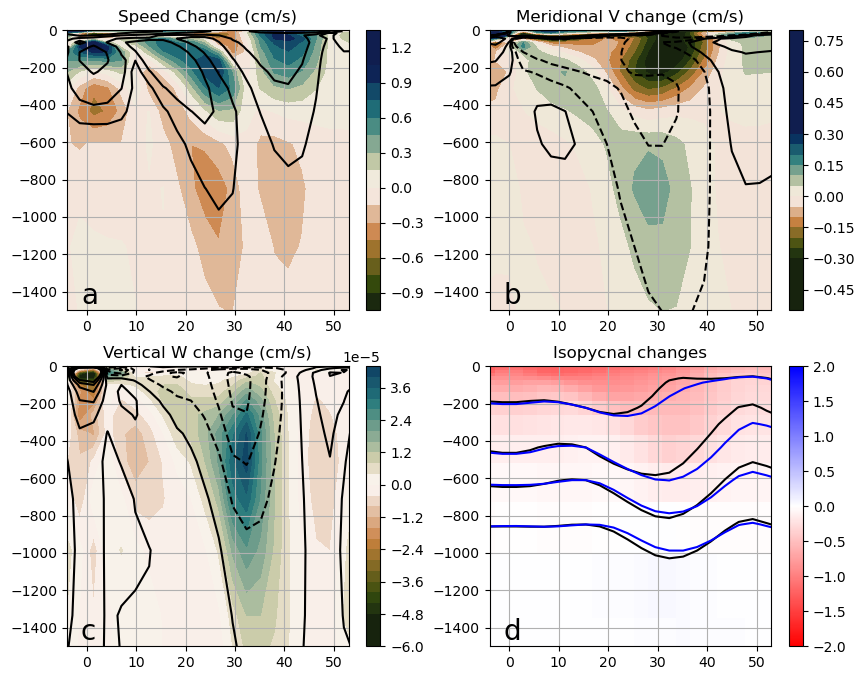

In [88]:
## putting these 4 simple figures together into one! Let's make two separate figures for now, but I think we can combine them later. 

fig, axs = plt.subplots(2,2,figsize=[10,8])
velmap = cmocean.cm.tarn


vm = 1
U = axs[0,0].contourf(PacTr.YC[ylow], PacTr.Z, 100*speeddif, vmin =-vm, vmax = vm,levels = 20, cmap = velmap)
plt.colorbar(U, ax = axs[0,0])
axs[0,0].contour(PacTr.YC[ylow], PacTr.Z,100*(myV**2 + myU**2)**0.5, levels = [1,2,5,10],colors = 'k')


vm = 0.3
A = axs[0,1].contourf(PacTS.YG[ylow+1], PacTS.Z,100*(myVpac-myV) , vmin =-vm, vmax = vm, levels = 30, cmap = velmap)
plt.colorbar(A, ax = axs[0,1])
axs[0,1].contour(PacTS.YG[ylow+1], PacTS.Z, 100*(myV), levels = [-0.5,-0.1, 0.1, 0.5, 2], colors = 'k')

plt.ylim([-2000,0])
plt.xlim([-50,55])
plt.grid()


vm = 0.00005

#plt.figure(figsize =[5,2])

myWpac = np.array(wvPac.isel(YC = ylow, XC =myX).mean('XC'))
myW = np.array(wvcon.isel(YC = ylow, XC =myX).mean('XC'))

W = axs[1,0].contourf(PacTS.YC[ylow], PacTS.Zl,100*(myWpac-myW) , vmin =-vm, vmax = vm, levels =30, cmap = velmap)
plt.colorbar(W, ax = axs[1,0])
axs[1,0].contour(PacTS.YC[ylow], PacTS.Zl,100*(myW), levels =  np.arange(-3e-4,3e-4, 5e-5),colors = 'k')

#plt.ylim([-2000,0])
#plt.xlim([-50,55])
#plt.grid()


#plt.figure(figsize =[5,4])
sigsouth =sigcon.isel(XC = myX, YC = ylow).mean('XC')
#signorth =sigcon.isel(XC = myX, YC = ylow+1)
sigPsouth = sigPac.isel(XC = myX, YC = ylow).mean('XC')
#sigPnorth = sigPac.isel(XC = myX, YC = ylow+1)

# OK finish this up real quick.
# pick a few contour levels that I want 
y30 = 12
siglevs = [sigsouth[8,y30],sigsouth[10, y30], sigsouth[11,y30], sigsouth[12,y30]] 
sigPlevs = [sigPsouth[8,y30], sigPsouth[10, y30], sigPsouth[11,y30], sigPsouth[12,y30]] 

I = axs[1,1].pcolor(PacTS.YC[ylow], PacTS.Z, sigPsouth - sigsouth, vmin = -2, vmax =2,cmap = 'bwr_r')
plt.colorbar(I, ax= axs[1,1])
axs[1,1].contour(PacTS.YC[ylow], PacTS.Z, sigsouth, colors = 'k', levels = siglevs, )
axs[1,1].contour(PacTS.YC[ylow], PacTS.Z, sigPsouth, colors = 'blue', levels = sigPlevs)
# axs[1,1].legend(['Control', 'Forced'])

plt.ylim([-1000,0])
plt.xlim([-5,53])
plt.grid()

lets = ['a','b','c','d']
for i in range(2):
    for j in range(2):
        axs[i,j].set_ylim([-1500,0])
        axs[i,j].set_xlim([-4,53])
        axs[i,j].grid()
        axs[i,j].text(0.05, 0.1, lets[(2*i+j)], fontsize=20, transform=axs[i,j].transAxes, ha='left', va='top')


#axs[1,1].set_ylim([-1000,0])

axs[0,0].set_title('Speed Change (cm/s)')
axs[0,1].set_title('Meridional V change (cm/s)')
axs[1,0].set_title('Vertical W change (cm/s)')
axs[1,1].set_title('Isopycnal changes')



#plt.savefig('eps_figures/uvw_sections7-24.eps')

In [195]:
# quick streamfunction calculation: 

vconf = vvcon.where(masks==1)#.mean('time')
transport = vconf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv = -transport.sum('XC').cumsum('Z')

vconPf = vvPac.where(masks==1)#.mean('time')
transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvP = -transportP.sum('XC').cumsum('Z')

netdif = netvP - netv

/glade/derecho/scratch/bataylor/tmp/ipykernel_62263/2516801296.py:77: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(I, ax= ax4)


Text(0.5, 1.0, 'Pacific Streamfunction changes')

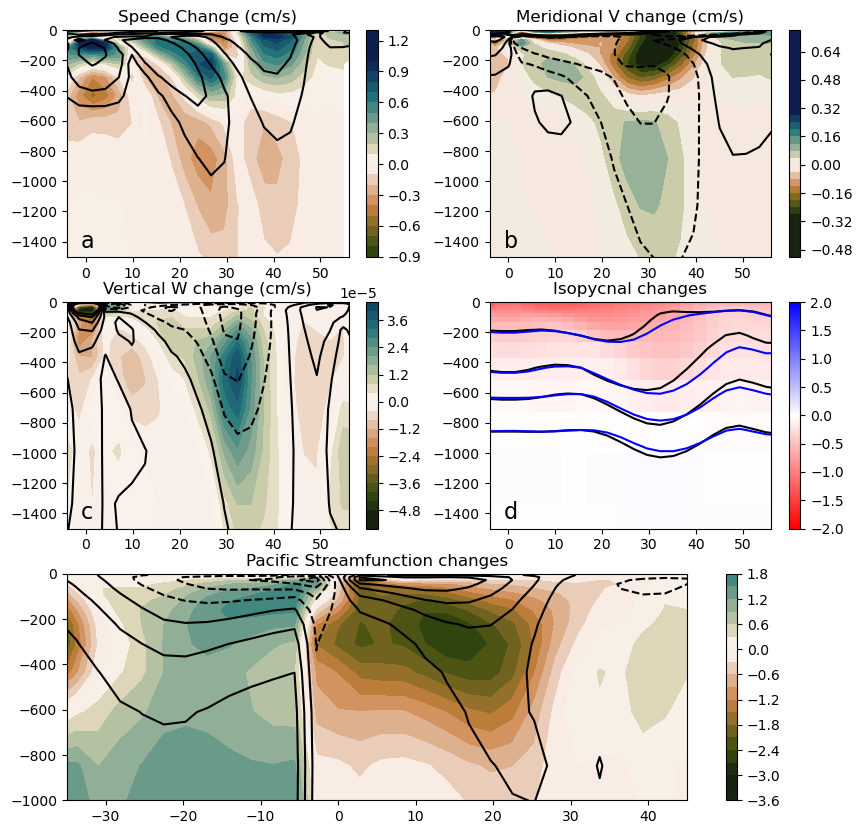

In [52]:
## putting these 4 simple figures together into one! Let's make two separate figures for now, but I think we can combine them later. 

# gonna add a 5th panel

#fig, axs = plt.subplots(2,2,figsize=[10,8])
velmap = cmocean.cm.tarn

#import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Create the figure
fig = plt.figure(figsize=(10, 10))

# Define a 3-row, 2-column grid
gs = gridspec.GridSpec(3, 2, height_ratios=[1, 1, 1])  # Equal height rows

# Create subplots
ax1 = fig.add_subplot(gs[0, 0])  # Row 0, Col 0
ax2 = fig.add_subplot(gs[0, 1])  # Row 0, Col 1
ax3 = fig.add_subplot(gs[1, 0])  # Row 1, Col 0
ax4 = fig.add_subplot(gs[1, 1])  # Row 1, Col 1
ax5 = fig.add_subplot(gs[2, :])  # Row 2, span all columns

# Optional: Add titles or labels for demo

# Adjust layout
#plt.tight_layout()
#plt.show()



vm = 1
U = ax1.contourf(PacTr.YC[ylow], PacTr.Z, 100*speeddif, vmin =-vm, vmax = vm,levels = 20, cmap = velmap)
plt.colorbar(U, ax = ax1)
ax1.contour(PacTr.YC[ylow], PacTr.Z,100*(myV**2 + myU**2)**0.5, levels = [1,2,5,10],colors = 'k')


vm = 0.3
A = ax2.contourf(PacTS.YG[ylow+1], PacTS.Z,100*(myVpac-myV) , vmin =-vm, vmax = vm, levels = 30, cmap = velmap) # why the weird thing? 
plt.colorbar(A, ax = ax2)
ax2.contour(PacTS.YG[ylow+1], PacTS.Z, 100*(myV), levels = [-0.5,-0.1, 0.1, 0.5, 2], colors = 'k')

plt.ylim([-2000,0])
plt.xlim([-50,55])
plt.grid()


vm = 0.00005

#plt.figure(figsize =[5,2])

myWpac = np.array(wvPac.isel(YC = ylow, XC =myX).mean('XC'))
myW = np.array(wvcon.isel(YC = ylow, XC =myX).mean('XC'))

W = ax3.contourf(PacTS.YC[ylow], PacTS.Zl,100*(myWpac-myW) , vmin =-vm, vmax = vm, levels =30, cmap = velmap)
plt.colorbar(W, ax = ax3)
ax3.contour(PacTS.YC[ylow], PacTS.Zl,100*(myW), levels =  np.arange(-3e-4,3e-4, 5e-5),colors = 'k')

#plt.ylim([-2000,0])
#plt.xlim([-50,55])
#plt.grid()


#plt.figure(figsize =[5,4])
sigsouth =sigcon.isel(XC = myX, YC = ylow).mean('XC')
#signorth =sigcon.isel(XC = myX, YC = ylow+1)
sigPsouth = sigPac.isel(XC = myX, YC = ylow).mean('XC')
#sigPnorth = sigPac.isel(XC = myX, YC = ylow+1)

# OK finish this up real quick.
# pick a few contour levels that I want 
y30 = 17
siglevs = [sigsouth[8,y30],sigsouth[10, y30], sigsouth[11,y30], sigsouth[12,y30]] 
sigPlevs = [sigPsouth[8,y30], sigPsouth[10, y30], sigPsouth[11,y30], sigPsouth[12,y30]] 

I = ax4.pcolor(PacTS.YC[ylow], PacTS.Z, sigPsouth - sigsouth, vmin = -2, vmax =2,cmap = 'bwr_r')
plt.colorbar(I, ax= ax4)
ax4.contour(PacTS.YC[ylow], PacTS.Z, sigsouth, colors = 'k', levels = siglevs, )
ax4.contour(PacTS.YC[ylow], PacTS.Z, sigPsouth, colors = 'blue', levels = sigPlevs)
# axs[1,1].legend(['Control', 'Forced'])

plt.ylim([-1000,0])
plt.xlim([-5,56])
plt.grid()

lets = ['a','b','c','d']
#for i in range(2):
#    for j in range(2):
#        axs[i,j].set_ylim([-1500,0])
#        axs[i,j].set_xlim([-4,56])
#        axs[i,j].grid()
#        axs[i,j].text(0.05, 0.1, lets[(2*i+j)], fontsize=20, transform=axs[i,j].transAxes, ha='left', va='top')

for i, ax in enumerate([ax1, ax2, ax3, ax4], 1):
    #ax.set_title(f"Subplot {i}")
    #ax.plot([0, 1], [0, i])
    ax.set_xlim([-4,56])
    ax.set_ylim([-1500,0])
    ax.text(0.05, 0.12, lets[i-1], fontsize=16, transform=ax.transAxes, ha='left', va='top')


ax5.contour(netv.YG, netv.Z, netv/1e6, levels = np.arange(-20, 25, 5), colors= 'k')
ax5.set_ylim([-1000,0])
ax5.set_xlim([-35,45])
PSI = ax5.contourf(netv.YG, netv.Z, netdif/1e6, vmin = -3, vmax = 3, levels = 20, cmap=velmap)
plt.colorbar(PSI, ax = ax5)

#axs[1,1].set_ylim([-1000,0])

ax1.set_title('Speed Change (cm/s)')
ax2.set_title('Meridional V change (cm/s)')
ax3.set_title('Vertical W change (cm/s)')
ax4.set_title('Isopycnal changes')
ax5.set_title('Pacific Streamfunction changes')



#plt.savefig('eps_figures/uvw_sections7-24.eps')

In [89]:
PacTr.XC[64:80]

<xarray.DataArray 'XC' (XC: 16)> Size: 64B
array([181.40625, 184.21875, 187.03125, 189.84375, 192.65625, 195.46875,
       198.28125, 201.09375, 203.90625, 206.71875, 209.53125, 212.34375,
       215.15625, 217.96875, 220.78125, 223.59375], dtype='>f4')
Coordinates:
  * XC       (XC) >f4 64B 181.4 184.2 187.0 189.8 ... 215.2 218.0 220.8 223.6

### one more attempt at remaking this figure

NameError: name 'speeddif' is not defined

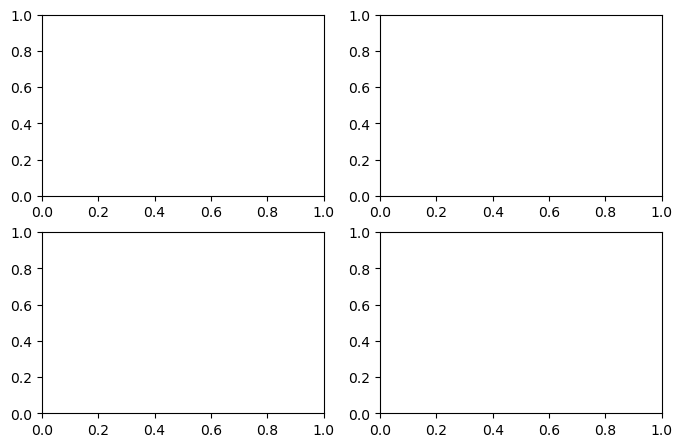

In [35]:
import matplotlib.gridspec as gridspec
# Create figure and subplots with gridspec to control width ratios

PacTr = PacPh
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(3, 2, figure=fig)

ylow = np.arange(20,53)
myX = np.arange(64,80)

# First two rows: normal width ratio (1:1)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

vm = 1
U = ax1.contourf(PacTr.YC[ylow], PacTr.Z, 100*speeddif, vmin =-vm, vmax = vm,levels = 20, cmap = velmap)
cb1 = plt.colorbar(U, ax = ax1)
ax1.contour(PacTr.YC[ylow], PacTr.Z,100*(myV**2 + myU**2)**0.5, levels = [1,2,5,10],colors = 'k', linewidths = 1.2)
cb1.ax.set_title('u (cm/s)',fontsize=10)

vm = 0.3
A = ax2.contourf(PacTS.YG[ylow+1], PacTS.Z,100*(myVpac-myV) , vmin =-vm, vmax = vm, levels = 30, cmap = velmap) # why the weird thing? 
cb2 = plt.colorbar(A, ax = ax2)
ax2.contour(PacTS.YG[ylow+1], PacTS.Z, 100*(myV), levels = [-0.5,-0.1, 0.1, 0.5, 2], colors = 'k', linewidths = 1.2)
cb2.ax.set_title('v (cm/s)',fontsize=10)
plt.ylim([-2000,0])
plt.xlim([-50,55])
plt.grid()


vm = 0.00005

#plt.figure(figsize =[5,2])

myWpac = np.array(wvPac.isel(YC = ylow, XC =myX).mean('XC'))
myW = np.array(wvcon.isel(YC = ylow, XC =myX).mean('XC'))

W = ax3.contourf(PacTS.YC[ylow], PacTS.Zl,100*(myWpac-myW) , vmin =-vm, vmax = vm, levels =30, cmap = velmap)
cb3 = plt.colorbar(W, ax = ax3)
ax3.contour(PacTS.YC[ylow], PacTS.Zl, 100*(myW), levels = np.arange(-3e-4,3e-4, 5e-5), colors = 'k',linewidths = 1.2)
#cb3.ax.set_title('w')
#plt.ylim([-2000,0])
#plt.xlim([-50,55])
#plt.grid()


#plt.figure(figsize =[5,4])
sigsouth =sigcon.isel(XC = myX, YC = ylow).mean('XC')
#signorth =sigcon.isel(XC = myX, YC = ylow+1)
sigPsouth = sigPac.isel(XC = myX, YC = ylow).mean('XC')
#sigPnorth = sigPac.isel(XC = myX, YC = ylow+1)

# OK finish this up real quick.
# pick a few contour levels that I want 
# this is so sketchy, I need to fix this ... 
y30 = np.argmin(np.abs(np.array(PacTS.YC[ylow]-40)))
siglevs = [sigsouth[8,y30],sigsouth[10, y30], sigsouth[11,y30], sigsouth[12,y30]] 
sigPlevs = [sigPsouth[8,y30], sigPsouth[10, y30], sigPsouth[11,y30], sigPsouth[12,y30]] 
# clev = np.linspace(-1,1,21)
I = ax4.pcolor(PacTS.YC[ylow], PacTS.Z, sigPsouth - sigsouth, vmin = -2, vmax =2,cmap = 'Spectral')
cb4 = plt.colorbar(I, ax= ax4)
cb4.ax.set_title('$\Delta \sigma_0$ (kg/m$^3$)', fontsize=10)
ax4.contour(PacTS.YC[ylow], PacTS.Z, sigsouth, colors = 'k', levels = siglevs, )
ax4.contour(PacTS.YC[ylow], PacTS.Z, sigPsouth, colors = 'r', linestyles = '--', levels = sigPlevs)
#ax4.legend(['Ctrl', 'Pac-4C'])

from matplotlib.lines import Line2D

    # Create proxy artists
legend_elements = [Line2D([0], [0], color='black', lw=1.5, label='Control'),
                    Line2D([0], [0], color='red', lw=1.5, linestyle='dashed', label='Pac-4C')]
ax4.legend(handles=legend_elements, loc='lower right')

    #plt.title('Two Sets of Contours with Legend')
    #plt.xlabel('X-axis')
    #plt.ylabel('Y-axis')
    #plt.show()
#plt.ylim([-1000,0])
#plt.xlim([-5,56])
ax4.grid()

lets = ['a','b','c','d']
#for i in range(2):
#    for j in range(2):
#        axs[i,j].set_ylim([-1500,0])
#        axs[i,j].set_xlim([-4,56])
#        axs[i,j].grid()
#        axs[i,j].text(0.05, 0.1, lets[(2*i+j)], fontsize=20, transform=axs[i,j].transAxes, ha='left', va='top')

for i, ax in enumerate([ax1, ax2, ax3, ax4], 1):
    #ax.set_title(f"Subplot {i}")
    ax.grid()
    ax.set_xlim([-30,56])
    ax.set_ylim([-1500,0])
    ax.text(0.05, 0.12, lets[i-1], fontsize=16, transform=ax.transAxes, ha='left', va='top')




# Third row: create subgrid with custom width ratio
sub_gs = gridspec.GridSpecFromSubplotSpec(
    1, 2, subplot_spec=gs[2, :], width_ratios=[1, 2]  # left thinner
)

ax5 = fig.add_subplot(sub_gs[0, 0])
ax6 = fig.add_subplot(sub_gs[0, 1])


#gs = fig.add_gridspec(1, 2, width_ratios=[1, 2])  # Left is twice as wide

# Left subplot (wider)
#ax1 = fig.add_subplot(gs[0])
#ax1.plot(x, y1, label='sin(x)', color='blue')
#ax1.set_title('Wider Plot')
#ax1.legend()

xran2 = myX
yran2 = np.arange(40,48)
zran2 = np.arange(0,17)
zranw = np.arange(0,18)


#PlA = wvSO.isel( XC = xran, YC = yran, Zl= zran).mean('XC').mean('YC')
PlB = wvPac.isel(  XC = xran2, YC = yran2, Zl= zranw).mean('XC').mean('YC')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = wvcon.isel( XC = xran2, YC = yran2, Zl= zranw).mean('XC').mean('YC')

ax3.set_title('w (cm/s)     ', loc = 'right', fontsize=10)
ax3.set_ylabel('z (m)')
ax1.set_ylabel('z (m)')
ax2.set_yticklabels([])
ax4.set_yticklabels([])
ax6.set_yticklabels([])


ax5.plot(Pl0, wvPac.Zl[zranw], 'k')
ax5.plot(PlB, wvPac.Zl[zranw], 'r--')
ax5.plot(PlB - Pl0, wvPac.Zl[zranw], 'gray')

ax5.legend(['Ctrl w', 'Pac4C w', '$\\Delta$ w'])
ax5.grid()
ax5.set_ylabel('z (m)')
ax5.set_xlabel('w (m/s)')

PlvP = vvPac.isel(  XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlvC = vvcon.isel( XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG')

vtr0  = PlvC  * PacTr.drF[zran2]
vtrP  = PlvP  * PacTr.drF[zran2]

# Right subplot (narrower)
#ax2 = fig.add_subplot(gs[1])
ax6.plot(np.cumsum(vtr0), PacTr.Zu[zran2])
ax6.plot(np.cumsum(vtrP), PacTr.Zu[zran2])
ax6.plot(np.cumsum(vtrP) - np.cumsum(vtr0), PacTr.Zu[zran2])

rad = 6371000
rot = 7.3e-5
#f= rot*2*np.sin(wvPac.YC[yran2]*np.pi/180)

#beta = rot*2/rad*np.cos(wvPac.YC[yran2]*np.pi/180)
taux = np.load('Yohei_2018/forcing_files_jan25/taux.npy')
tauy = np.load('Yohei_2018/forcing_files_jan25/tauy.npy')
tauxd = np.sum(taux[yran2[0], xran2]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2[0])) -taux[yran2[-1], xran2]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2[-1])))
tauyd = np.sum(tauy[yran2, xran2[-1]]*np.array(SOTr.dyC.isel(XC = xran2[-1], YG = yran2)) - tauy[yran2, xran2[0]]*np.array(SOTr.dyC.isel(XC = xran2[0], YG = yran2)))
tauxd2 = np.sum(taux[yran2[0]-1, xran2]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2[0]-1)) -taux[yran2[-1]+1, xran2]*np.array(SOTr.dxC.isel(XG=xran2, YC=yran2[-1]+1)))
tauyd2 = np.sum(tauy[yran2, xran2[-1]+1]*np.array(SOTr.dyC.isel(XC = xran2[-1]+1, YG = yran2)) - tauy[yran2, xran2[0]-1]*np.array(SOTr.dyC.isel(XC = xran2[0]-1, YG = yran2)))
mycurl = (tauxd+tauyd + tauxd2+ tauyd2) / np.array(SOTr.rA.isel(XC = xran2, YC = yran2).sum('XC').sum('YC')) / 2

beta= 2*np.cos(np.array(SOTr.YG[44]/180) * np.pi)/6370000 * 7.3e-5
f= rot*2*np.sin(wvPac.YC[yran2]*np.pi/180)

wdif = PlB-Pl0
#wprofP = -wvPac.isel(XC = xran2, YC = yran2, Zl= zran2).mean('XC').mean('YC') 
#wPl2 = (wprofP - wprofP[3])/np.mean(beta)*np.mean(f) 
ax6.plot(-wdif/np.mean(beta)*np.mean(f), wvPac.Zl[zranw], 'gray')

ax6.plot(0*PacTr.Zu[zran2] + mycurl/1035/beta, PacTr.Zu[zran2], 'k--')
#plt.plot(wPl2 , wvPac.Zl[zran2], 'red')
ax6.legend(['Ctrl $\int_z^0 v$ ', 'Pac4C $\int_z^0 v$ ', '$\Delta$ $\int_z^0 v$ ', '$\Delta$w*(-f)/$\\beta$'], ncol=2, fontsize = 10) #  '$\\nabla$x($\\tau)/\\rho_0 / \\beta$'], 
ax6.grid()
ax6.set_xlabel('Meridional Transport (m$^2$/s)')

ax5.text(0.05, 0.74, 'e', fontsize=16, transform=ax5.transAxes, ha='left', va='top')
ax6.text(0.09, 0.74, 'f', fontsize=16, transform=ax6.transAxes, ha='left', va='top')

plt.tight_layout()

# plt.savefig('eps_figures/vel_combined11-29_grids.eps')

In [58]:
#y30 = 
#np.argmin(np.abs(PacTS.YC[ylow]-30))

In [121]:
np.argmin(np.abs(np.array(PacTS.YC[ylow]-30)))

22

In [93]:
#PlA = wvSO.isel( XC = xran, YC = yran, Zl= zran).mean('XC').mean('YC')
PlB = vvPac.isel(  XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG').mean('time')
#PlC = o2C.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlD = o2D.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = vvcon.isel( XC = xran2, YG = yran2, Z= zran2).mean('XC').mean('YG').mean('time')

plt.plot(100*Pl0, vvPac.Z[zran2], 'k')
plt.plot(100*PlB, vvPac.Z[zran2], 'r--')
plt.plot(100*(PlB - Pl0), vvPac.Z[zran2], 'gray')

plt.legend(['Control v', 'Pac-Warming v', 'Difference'])
plt.grid()

# OK let's see how this transport looks! 
vtr0  = Pl0  * PacTr.drF[zran2]
vtrP  = PlB  * PacTr.drF[zran2]

ValueError: 'time' not found in array dimensions ('Z',)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

$\Delta h/\Delta g' = (-1/2) h/g' \rightarrow \Delta h = (-1/2) (\Delta g' / g') h $ 

$\Delta g'/g' = 0.36 $


$\Delta h = (-1/2) (0.36)h$

In [7]:
# new version
vvSO = xr.where(SOTr.VVEL ==0, np.nan, SOTr.VVEL).mean('time')
vvSO50 = xr.where(SOTr.VVEL ==0, np.nan, SO50Tr.VVEL).mean('time')
#wvcon= xr.where(CtlTr.WVEL ==0, np.nan, CtlTr.WVEL)
vvcon= xr.where(CtlTr.VVEL ==0, np.nan, CtlTr.VVEL).mean('time')
vvPac = wvSO50 # just in case

NameError: name 'SO50Tr' is not defined

In [ ]:
## OK now I'm trying overturning circulation, again! 
# I think you just integrate from the bottom, but I can try integrating from the surface. 
# I also think I need to have a Pacific mask 

In [8]:
#wvPac, wvcon
masks = np.load('Yohei_2018/forcing_files_jan25/masks.npy')
vconP = vvcon.where(masks==1)#.mean('time')
transport = vconP*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv = transport.sum('XC').cumsum('Z')

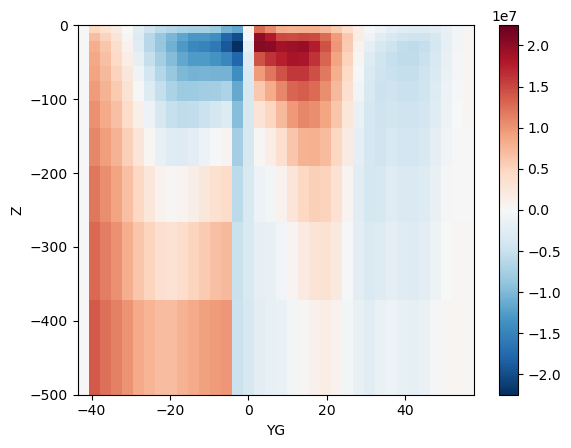

In [9]:
vconPf = vvPac.where(masks==1)#.mean('time')
transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvP = transportP.sum('XC').cumsum('Z')
netv.isel(YG=range(17,53)).plot(ylim=[-500,0])

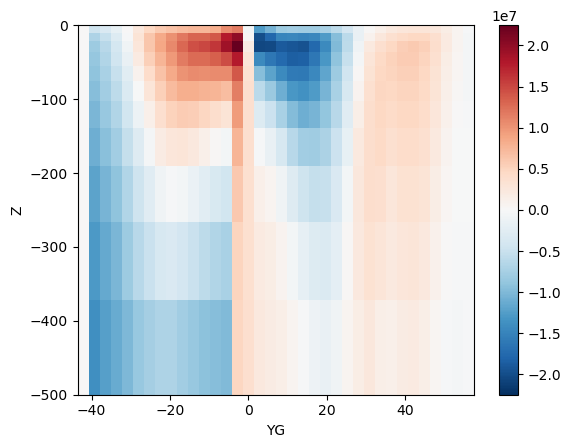

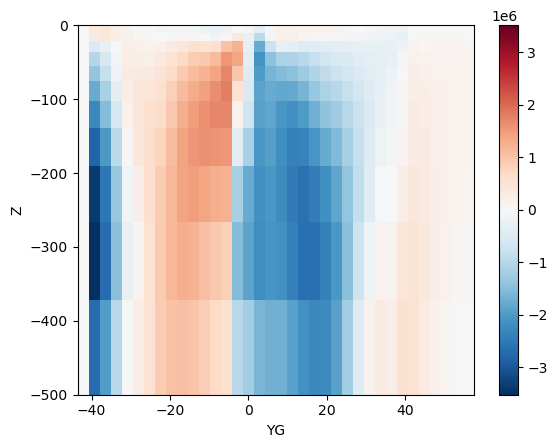

In [11]:
netdif = netvP - netv
netdif.isel(YG=range(17,53)).plot(ylim=[-500,0])

In [177]:
# how much does the proposed STCI decrease by? 
print((np.array(np.max(netv)) - np.array(np.min(netv)))/1e6 )
print((np.array(np.max(netvP)) - np.array(np.min(netvP)))/1e6 )

42.925424
40.754176


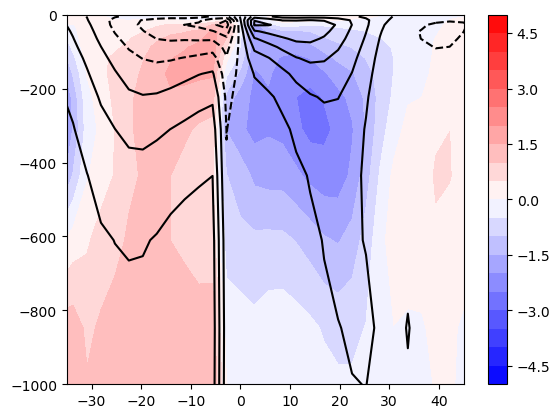

In [12]:
## Ok Let's try and make a subpanel first: 

plt.contour(netv.YG, netv.Z, netv/1e6, levels = np.arange(-20, 25, 5), colors= 'k')
plt.ylim([-1000,0])
plt.xlim([-35,45])
plt.contourf(netv.YG, netv.Z, netdif/1e6, vmin = -5, vmax = 5, levels = np.linspace(-5,5,21), cmap='bwr')
plt.colorbar()


In [26]:
vconf = vvcon.where(masks==1)#.mean('time')
transport = vconf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv2 = -transport.sum('XC').cumsum('Z')

vconSf2 = vvSO.where(masks==1)#.mean('time')
transportS2 = vconSf2*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO3 = -transportS2.sum('XC').cumsum('Z')

#netdifSO2 = netvSO3 - netv2

In [27]:
print((np.array(np.max(netv2)) - np.array(np.min(netv2)))/1e6 )
print((np.array(np.max(netvSO3)) - np.array(np.min(netvSO3)))/1e6 )

42.925424
43.483556


/glade/derecho/scratch/bataylor/tmp/ipykernel_54227/3498722870.py:3: RuntimeWarning: invalid value encountered in divide
  pma = pma/pma


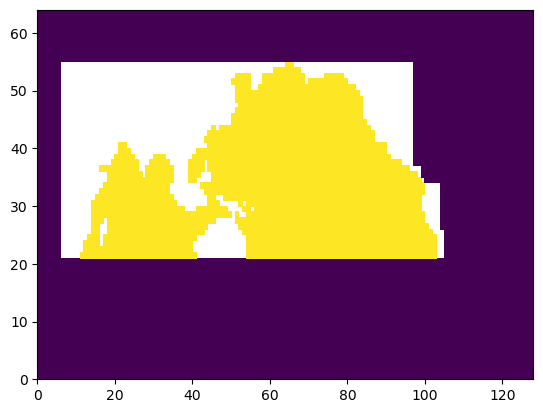

In [19]:
# real quick let's make an Indian basin mask. Tricky.. 
pma = np.array(conPh.hFacC.isel(Z=0))
pma = pma/pma
#plt.pcolor(pma)


IPmask = pma
IPmask[0:21, :] = 0 
IPmask[55:64, :] = 0 
IPmask[:, 0:6] = 0 
#IPmask[:, 0:33] = 0 
IPmask[:, 105:] = 0 
IPmask[50:64, 100:] = 0 #

#AllTmask = TPmask
#IPmask[26:39, 0:36] = 0
IPmask[26:39, 104:]=0
IPmask[34:55, 100:]=0
IPmask[35:55, 99:]=0
IPmask[37:55, 97:]=0
#IPmask[17:31, 33:50] = 0
#TPmask[18:31, 33:50] = 0
plt.pcolor(IPmask)

In [25]:
# try SO


#vconf = vvcon.where(masks==1)#.mean('time')
#transport = vconf*vvcon.drF*vvcon.hFacS*vvcon.dxG
#netv2 = -transport.sum('XC').cumsum('Z')

vconf = vvcon.where(IPmask==1)#.mean('time')
transport = vconf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv2 = transport.sum('XC').cumsum('Z')

#vconSf = vvSO.where(masks==1)#.mean('time')
vconSf = vvSO.where(IPmask==1)#.mean('time')
transportS = vconSf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO = transportS.sum('XC').cumsum('Z')

netdifSO = netvSO - netv2

#vconPf = vvPac.isel(XC = range(12,103), YG = range(17,54)).mean('time')
#transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
#netvP = transportP.sum('XC').cumsum('Z')

In [142]:
# try SO 50S!
#masks = np.load('Yohei_2018/forcing_files_jan25/masks.npy')
vconP = vvcon.where(IPmask==1)#.mean('time')
transport = -vconP*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv = transport.sum('XC').cumsum('Z')


#vconSf50 = vvSO50.where(masks==1)#.mean('time')
vconSf50 = vvSO50.where(IPmask==1)#.mean('time')
transportS50 = vconSf50*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO50 = -transportS50.sum('XC').cumsum('Z')

netdifSO50 = netvSO50 - netv

#vconPf = vvPac.isel(XC = range(12,103), YG = range(17,54)).mean('time')
#transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
#netvP = transportP.sum('XC').cumsum('Z')

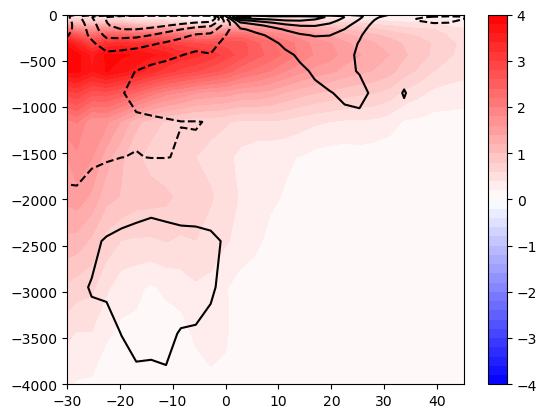

In [26]:
## Ok Let's try and make a subpanel first: 

plt.contour(netv.YG, netv.Z, netv2/1e6, levels = np.arange(-20, 25, 5), colors= 'k')
plt.ylim([-4000,0])
plt.xlim([-30,45])
vm = 4
plt.contourf(netv.YG, netv.Z, netdifSO/1e6, vmin = -vm, vmax =vm, levels = np.linspace(-vm, vm,41) , cmap='bwr')
plt.colorbar()


In [20]:


vconf = vvcon.where(IPmask==1)#.mean('time')
transport = vconf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv2 = -transport.sum('XC').cumsum('Z')

vconSf2 = vvSO.where(IPmask==1)#.mean('time')
transportS2 = vconSf2*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO2 = -transportS2.sum('XC').cumsum('Z')

netdifSO2 = netvSO2 - netv2

## Ok Let's try and make a subpanel first: 

axs[0].contour(netv.YG, netv.Z, netv/1e6, levels = np.arange(-20, 25, 5), colors= 'k')
axs[0].set_ylim([-1000,0])
axs[0].set_xlim([-35,40])
A = axs[0].contourf(netv.YG, netv.Z, netdif/1e6, vmin = -5, vmax = 5, levels = np.linspace(-5,5,21), cmap='bwr')
plt.colorbar(A, ax = axs[0])

axs[1].contour(netv.YG, netv.Z, netv2/1e6, levels = np.arange(-20, 25, 5), colors= 'k')
axs[1].set_ylim([-4000,0])
axs[1].set_xlim([-30,40])
B = axs[1].contourf(netv.YG, netv.Z, netdifSO2/1e6, vmin = -5, vmax = 5, levels =np.linspace(-5,5,21), cmap='bwr')
plt.colorbar(B, ax = axs[1])


#vconPf = vvPac.isel(XC = range(12,103), YG = range(17,54)).mean('time')
#transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
#netvP = transportP.sum('XC').cumsum('Z')

NameError: name 'netdif' is not defined

Text(0.65, 0.4, 'STCI(SO-4C)=43.3 Sv')

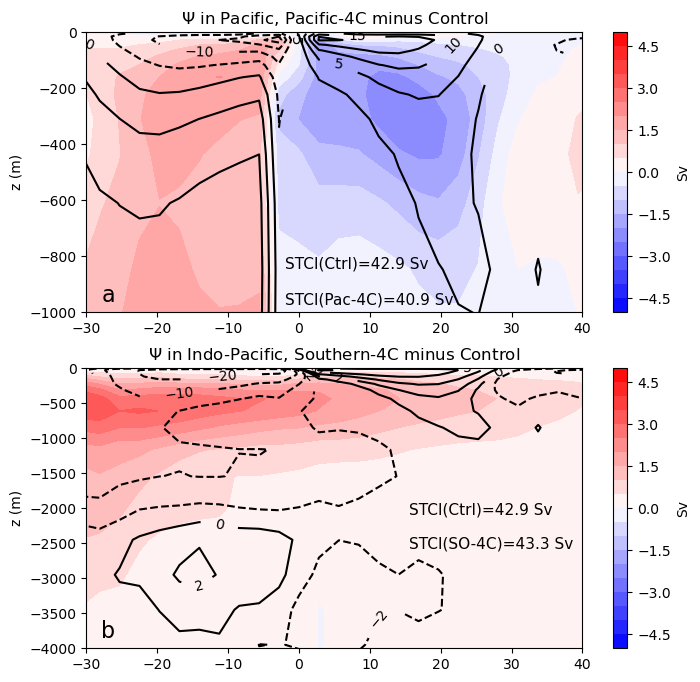

In [21]:
# Figure 8 

fig, axs = plt.subplots(nrows=2, figsize=(8,8))

#wvPac, wvcon
masks = np.load('Yohei_2018/forcing_files_jan25/masks.npy')
vconP = vvcon.where(masks==1)#.mean('time')
transport = vconP*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv = transport.sum('XC').cumsum('Z')

vconPf = vvPac.where(masks==1)#.mean('time')
transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvP = transportP.sum('XC').cumsum('Z')
#netv.isel(YG=range(17,53)).plot(ylim=[-500,0])



vconf = vvcon.where(IPmask==1)#.mean('time')
transport = vconf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv2 = transport.sum('XC').cumsum('Z')

vconSf2 = vvSO.where(IPmask==1)#.mean('time')
transportS2 = vconSf2*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO2 = transportS2.sum('XC').cumsum('Z')

netdifSO2 = netvSO2 - netv2

## 

cl = axs[0].contour(netv.YG, netv.Z, netv/1e6, levels = np.arange(-20, 25, 5), colors= 'k')
cl.clabel()
axs[0].set_ylim([-1000,0])
axs[0].set_xlim([-30,40])
A = axs[0].contourf(netv.YG, netv.Z, (netvP - netv)/1e6, vmin = -5, vmax = 5, levels = np.linspace(-5,5,21), cmap='bwr')
cb1 = plt.colorbar(A, ax = axs[0])
cb1.set_label('Sv')
axs[0].set_title('$\\Psi$ in Pacific, Pacific-4C minus Control') 
axs[0].set_ylabel('z (m)')


iplevs = [-20,-10,-5,-2,0,2, 5, 10,  20]
cl2 = axs[1].contour(netv.YG, netv.Z, netv2/1e6, levels = iplevs, colors= 'k')
cl2.clabel( )
axs[1].set_ylim([-4000,0])
axs[1].set_xlim([-30,40])
B = axs[1].contourf(netv.YG, netv.Z, netdifSO2/1e6, vmin = -5, vmax = 5, levels =np.linspace(-5,5,21), cmap='bwr')
cb2= plt.colorbar(B, ax = axs[1])
cb2.set_label('Sv')
axs[1].set_title('$\\Psi$ in Indo-Pacific, Southern-4C minus Control')
axs[1].set_ylabel('z (m)')


axs[0].text(0.03, 0.1, 'a', fontsize=16, transform=axs[0].transAxes, ha='left', va='top')
axs[0].text(0.4, 0.2, 'STCI(Ctrl)=42.9 Sv', fontsize=11, transform=axs[0].transAxes, ha='left', va='top')
axs[0].text(0.4, 0.07, 'STCI(Pac-4C)=40.9 Sv', fontsize=11, transform=axs[0].transAxes, ha='left', va='top')
#40.754176

axs[1].text(0.03, 0.1, 'b', fontsize=16, transform=axs[1].transAxes, ha='left', va='top')
axs[1].text(0.65, 0.52, 'STCI(Ctrl)=42.9 Sv', fontsize=11, transform=axs[1].transAxes, ha='left', va='top')
axs[1].text(0.65, 0.4, 'STCI(SO-4C)=43.3 Sv', fontsize=11, transform=axs[1].transAxes, ha='left', va='top')


#plt.savefig('eps_figures/Streamfunctions11-29_2.eps')

In [43]:
print((np.array(np.max(netv)) - np.array(np.min(netv)))/1e6 )
print((np.array(np.max(netvP)) - np.array(np.min(netvP)))/1e6 )
#print((np.array(np.max(netv2)) - np.array(np.min(netv2)))/1e6 )
print((np.array(np.max(netvSO3)) - np.array(np.min(netvSO3)))/1e6 )

42.925424
40.855752
43.320852


In [42]:
vconSf3 = vvSO.where(masks==1)
transportS3 = vconSf3*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvSO3 = transportS3.sum('XC').cumsum('Z')

In [ ]:
# This is OK! I'm clearly stressed out. 
# A couple things. I don't understand this that well because I haven't made so many overturning plots. 
# I think the disconnect at the ITF is typical. There is return transport by the Agulhas that's missing... 
# but that makes it very hard to do the STCI very well ... 

# if I can get this to look presentable I can make this a good figure, because it shows weakening of the STC transport. 
# I have several thoughts. 
# One is that I really should learn how most Pacific streamfunctions deal with the ITF. 
# maybe they integrate from depth. no that doesn't matter. There's a reality that a lot of water comes up from the South Pacific a
# flows through the ITF. there must be a standard deal with this. 

# yeah standard is to use Indo-Pacific. 
# I believe the STCI is dependent on ITF transport. Read duteil and think about it. 
# I also feel like STCI is totally just how much Ekman divergence do you get? 
# but there may be another aspect as well ... 
# done thinking about that for now. 

In [ ]:
# I feel like 180-135 would be reasonable, and could have clean values ... 

In [2]:
# try  indian 

# quick streamfunction calculation: 

vconf = vvcon.where(IPmask==1)#.mean('time')
transport = vconf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netv2 = -transport.sum('XC').cumsum('Z')

vconPf = vvPac.where(IPmask==1)#.mean('time')
transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
netvP2 = -transportP.sum('XC').cumsum('Z')

netdif2 = netvP2 - netv2

#vconPf = vvPac.isel(XC = range(12,103), YG = range(17,54)).mean('time')
#transportP = vconPf*vvcon.drF*vvcon.hFacS*vvcon.dxG
#netvP = transportP.sum('XC').cumsum('Z')

NameError: name 'vvcon' is not defined

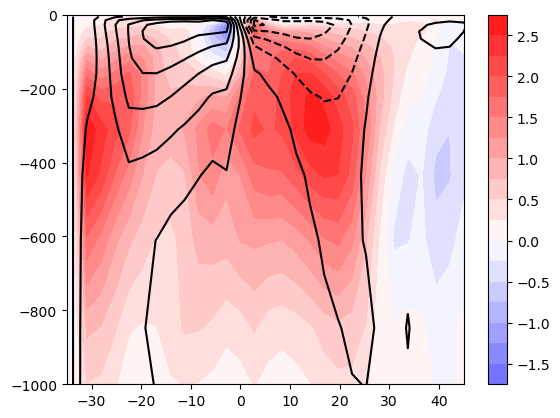

In [220]:
## Ok Let's try and make a subpanel first: 

plt.contour(netv.YG, netv.Z, netv2/1e6, levels = np.arange(-25, 40, 5), colors= 'k')
plt.ylim([-1000,0])
plt.xlim([-35,45])
plt.contourf(netv.YG, netv.Z, netdif2/1e6, vmin = -3, vmax = 3, levels = 20, cmap='bwr')
plt.colorbar()


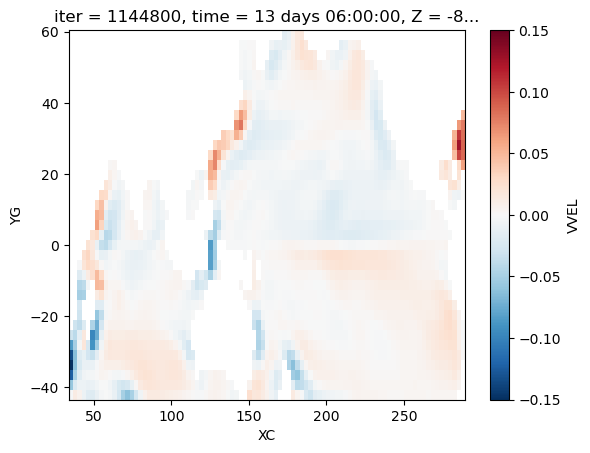

In [582]:
vvcon.isel(Z=5, XC = range(12,103), YG = range(17,54), time=0).plot()

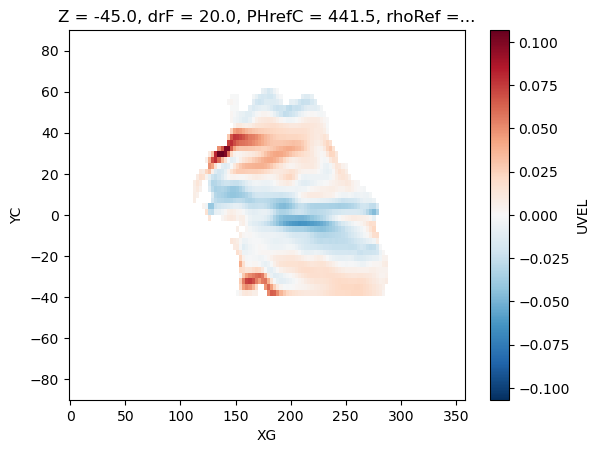

In [554]:
tst= uvcon.where(masks==1)#.mean('time')
tst.isel(Z=3).plot()

In [83]:
wvcon.shape

(23, 64, 128)

In [4]:
myYrTS = np.arange(90*720,100*720,60)
#print(myYr)
myItsTS = 2880000 + myYrTS

In [91]:
# random MLD test 

fol0 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/Control_try1/'
folGl = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4Cstep_try1/'
fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'

SO2d = xmitgcm.open_mdsdataset(folGl, grid_dir = fol3, prefix = 'Diag2d', iters = myItsTS.tolist(), ignore_unknown_vars = True)
Ctl2d = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = 'Diag2d', iters = myItsTS.tolist(), ignore_unknown_vars = True)


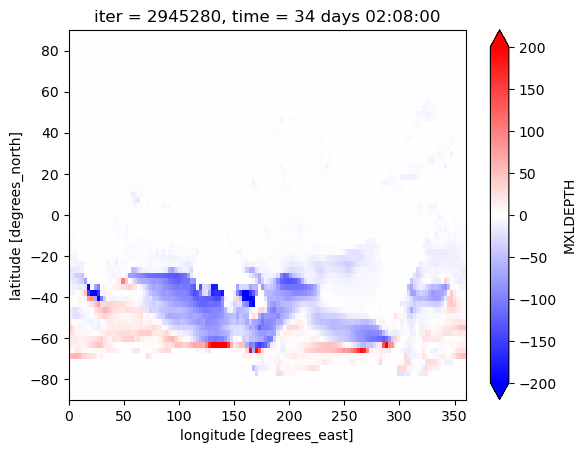

In [92]:
a = SO2d.MXLDEPTH.isel(time=8) - Ctl2d.MXLDEPTH.isel(time=8)
a.plot(vmin = -200, vmax = 200, cmap = 'bwr')

In [96]:
Ctl2d.MXLDEPTH

<xarray.DataArray 'MXLDEPTH' (time: 120, YC: 64, XC: 128)> Size: 4MB
dask.array<concatenate, shape=(120, 64, 128), dtype=float32, chunksize=(1, 64, 128), chunktype=numpy.ndarray>
Coordinates:
    iter     (time) int64 960B dask.array<chunksize=(1,), meta=np.ndarray>
  * time     (time) timedelta64[ns] 960B 34 days 02:00:00 ... 34 days 03:59:00
  * XC       (XC) >f4 512B 1.406 4.219 7.031 9.844 ... 350.2 353.0 355.8 358.6
  * YC       (YC) >f4 256B -88.59 -85.78 -82.97 -80.16 ... 82.97 85.78 88.59
    rA       (YC, XC) >f4 33kB dask.array<chunksize=(64, 128), meta=np.ndarray>
    Depth    (YC, XC) >f4 33kB dask.array<chunksize=(64, 128), meta=np.ndarray>
    dyF      (YC, XC) >f4 33kB dask.array<chunksize=(64, 128), meta=np.ndarray>
    dxF      (YC, XC) >f4 33kB dask.array<chunksize=(64, 128), meta=np.ndarray>
Attributes:
    standard_name:  MXLDEPTH
    long_name:      Mixed-Layer Depth (>0)
    units:          m

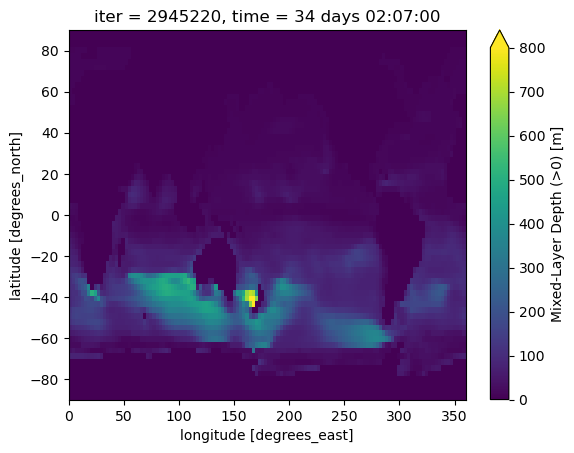

In [57]:
Ctl2d.MXLDEPTH.isel(time=7).plot(vmax = 800)

In [ ]:
# let's try to compare with obser

In [23]:
obMLD = xr.open_dataset('Argo_MLD.nc')

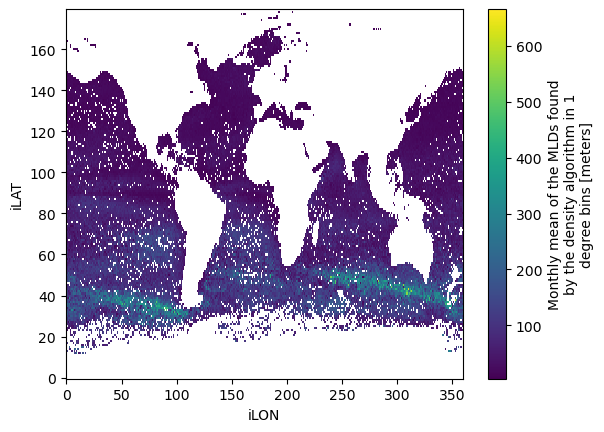

In [31]:
obMLD.mld_da_mean.isel(iMONTH = 7).plot()

In [86]:
testfil = obMLD.mld_da_mean.interpolate_na(dim = 'iLON', limit = 1).interpolate_na(dim = 'iLAT', limit = 1)#.isel(iMONTH = 7).plot()

In [41]:
test = obMLD.mld_da_mean.assign_coords(iLAT = np.arange(-90,90))

In [95]:
# great now we just need to interpolate it to the new version 
newlon = np.concatenate([np.arange(180,360), np.arange(0,180)])
MLDint = testfil.assign_coords(iLAT = np.arange(-90,90)).assign_coords(iLON = newlon)
MLDint = MLDint.sortby('iLON')
MLDint = MLDint.interp( iLAT = Ctl2d.YC, iLON = Ctl2d.XC, method = 'linear')


In [73]:
MLDint.month

<xarray.DataArray 'mld_da_mean' (YC: 64, XC: 128, iMONTH: 12)> Size: 786kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
    iLAT     (YC) >f4 256B -88.59 -85.78 -82.97 -80.16 ... 82.97 85.78 88.59
    iLON     (XC) >f4 512B 1.406 4.219 7.031 9.844 ... 350.2 353.0 355.8 358.6
  * YC       (YC) >f4 256B -88.59 -85.78 -82.97 -80.16 ... 82.97 85.78 88.59
  * XC       (XC) >f4 512B 1.406 4.219 7.031 9.844 ... 350.2 353.0 355.8 358.6
Dimensions without coordinates: iMONTH
Attributes:
    long_name:        Monthly mean of the MLDs found by the density algorithm...
    standard_name:    mld_da_mean
    units:            meters
    _CoordinateAxis:  month lat lon
    valid_min:        95.0
    valid_max:        110.0
    title:            Monthly mean of the MLDs found by the density algorithm...
    institution:      SIO

In [76]:
MLDint.XC

<xarray.DataArray 'XC' (XC: 128)> Size: 512B
array([  1.40625,   4.21875,   7.03125,   9.84375,  12.65625,  15.46875,
        18.28125,  21.09375,  23.90625,  26.71875,  29.53125,  32.34375,
        35.15625,  37.96875,  40.78125,  43.59375,  46.40625,  49.21875,
        52.03125,  54.84375,  57.65625,  60.46875,  63.28125,  66.09375,
        68.90625,  71.71875,  74.53125,  77.34375,  80.15625,  82.96875,
        85.78125,  88.59375,  91.40625,  94.21875,  97.03125,  99.84375,
       102.65625, 105.46875, 108.28125, 111.09375, 113.90625, 116.71875,
       119.53125, 122.34375, 125.15625, 127.96875, 130.78125, 133.59375,
       136.40625, 139.21875, 142.03125, 144.84375, 147.65625, 150.46875,
       153.28125, 156.09375, 158.90625, 161.71875, 164.53125, 167.34375,
       170.15625, 172.96875, 175.78125, 178.59375, 181.40625, 184.21875,
       187.03125, 189.84375, 192.65625, 195.46875, 198.28125, 201.09375,
       203.90625, 206.71875, 209.53125, 212.34375, 215.15625, 217.96875,
       220.78125, 223.59375, 226.40625, 229.21875, 232.03125, 234.84375,
       237.65625, 240.46875, 243.28125, 246.09375, 248.90625, 251.71875,
       254.53125, 257.34375, 260.15625, 262.96875, 265.78125, 268.59375,
       271.40625, 274.21875, 277.03125, 279.84375, 282.65625, 285.46875,
       288.28125, 291.09375, 293.90625, 296.71875, 299.53125, 302.34375,
       305.15625, 307.96875, 310.78125, 313.59375, 316.40625, 319.21875,
       322.03125, 324.84375, 327.65625, 330.46875, 333.28125, 336.09375,
       338.90625, 341.71875, 344.53125, 347.34375, 350.15625, 352.96875,
       355.78125, 358.59375], dtype='>f4')
Coordinates:
    iLON     (XC) >f4 512B 1.406 4.219 7.031 9.844 ... 350.2 353.0 355.8 358.6
  * XC       (XC) >f4 512B 1.406 4.219 7.031 9.844 ... 350.2 353.0 355.8 358.6
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    coordinate:     YC XC
    axis:           X

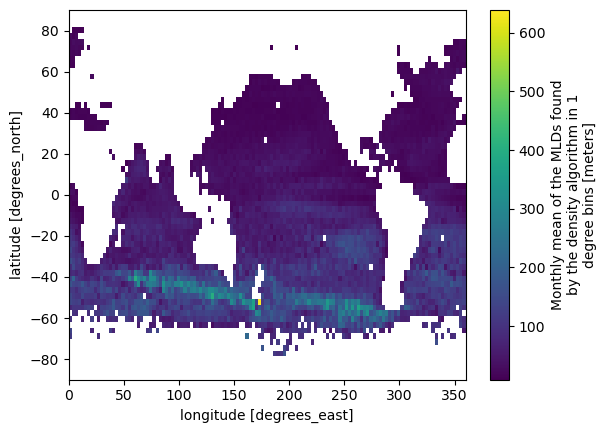

In [98]:
MLDint.isel(iMONTH=7).plot()

#lon = o2an.lon

# if your lon is not a plain 1D coordinate, adapt accordingly
#new_lon = ((lon + 280) % 360) - 280

# assign new coordinate labels (this does NOT move data)
#woa = o2an.assign_coords(lon=new_lon)

# then sort longitude values so they run from -280 -> 80
#woa = woa.sortby('lon')

# verify
#print(woa.lon.min().item(), woa.lon.max().item())
# should show: -280.0 80.0
#o2_interp = woa.interp(lat=samtest["yh"], lon=samtest["xh"], method='linear')


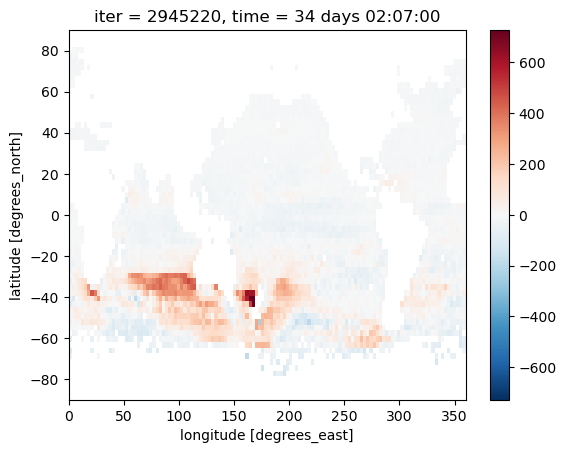

In [90]:
MLDdiff = Ctl2d.MXLDEPTH.isel(time=7) - MLDint.isel(iMONTH=7)
MLDdiff.plot()

/glade/derecho/scratch/bataylor/tmp/ipykernel_42860/1243145055.py:39: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cb = fig.colorbar(a, cax=cax, shrink = 0.5)


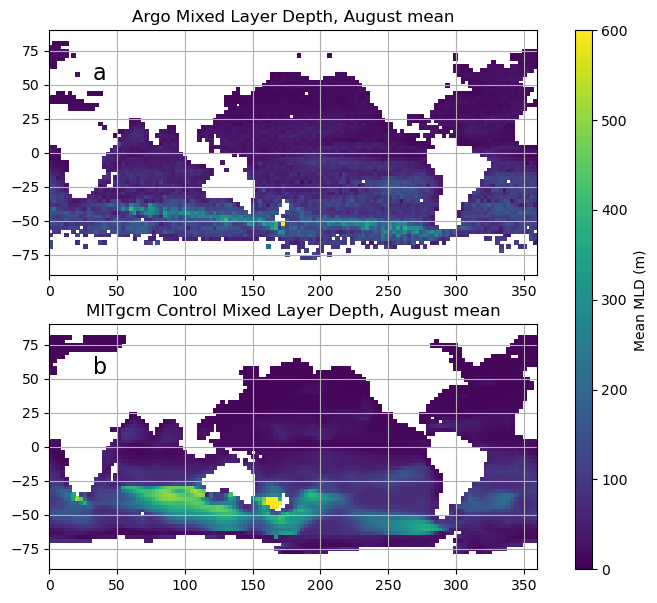

In [129]:
# Let's make a nice figure that compares the two. 

fig = plt.figure(figsize=(7, 7))

gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[30, 1],   # main panels + colorbar
    wspace=0.15,
    hspace=0.2
)

# main axes
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])

# colorbar axis (spans both rows)
cax = fig.add_subplot(gs[:, 1])


#fig,axs = plt.subplots(nrows = 2, ncols=1, figsize=([6,7]))
vmin = 0
vmax = 600
toPl = Ctl2d.MXLDEPTH.isel(time = 7).where(Ctl2d.MXLDEPTH.isel(time=7)!=0, other=np.nan)
a=ax0.pcolor(Ctl2d.MXLDEPTH.XC, Ctl2d.MXLDEPTH.YC, MLDint.isel(iMONTH=7), vmin = vmin, vmax = vmax)
b=ax1.pcolor(Ctl2d.MXLDEPTH.XC, Ctl2d.MXLDEPTH.YC, toPl, vmin = vmin, vmax = vmax)

ax0.text(0.09, 0.87, 'a', fontsize=16, transform=ax0.transAxes,ha='left', va='top')
ax1.text(0.09, 0.87, 'b', fontsize=16, transform=ax1.transAxes,ha='left', va='top')
ax0.grid()
ax1.grid()
ax0.set_title('Argo Mixed Layer Depth, August mean')
ax1.set_title('MITgcm Control Mixed Layer Depth, August mean')


# shared colorbar
cb = fig.colorbar(a, cax=cax, shrink = 0.5)
cb.set_label('Mean MLD (m)')
#plt.colorbar(b, ax = axs[1], label='Mean MLD (m)')
#plt.colorbar(a, ax = axs[0], label='Mean MLD (m)')
#cax = fig.add_axes([0.92, 0.55, 0.02, 0.32])  # [left, bottom, width, height]
#cbmap = plt.colorbar(a, cax=axs[0], label='Mean MLD (m)')

#MLDdiff = Ctl2d.MXLDEPTH.isel(time=7) - MLDint.isel(iMONTH=7)

#MLDdiff.plot()
# plt.savefig('eps_figures/MLD_supp_12-22.eps', bbox_inches="tight")